# Galaxy Density Profile Fits — Data Products Tutorial

This notebook explains how to read and use the CSV and HDF5 output files
produced by `fitGalaxies_tnfw_jaffe_dual.py`. It covers:

1. **Background & physical model**
2. **CSV file structure** — best-fit parameters and derived quantities
3. **HDF5 file structure** — per-sample MCMC fit parameters
4. **Reproducing density profiles** — DM + Jaffe and each component separately
5. **Error estimation from MCMC samples** — posterior envelopes
6. **Derived quantities** — $c_{200}$, $R_{200}$, $M_{200}$

---

## 1. Background & Physical Model

### Overview

Each galaxy in a galaxy cluster has its total mass distribution modelled by
the LensTool code as a **PIEMD** (Pseudo-Isothermal Elliptical Mass
Distribution). The fitting code *decomposes* this total PIEMD profile into a
**dark-matter (DM) component** plus a **stellar component**, assuming
spherical symmetry for the 3-D density profile:

$$\rho_{\mathrm{total}}(r) = \rho_{\mathrm{DM}}(r) + \rho_{\star}(r)$$

### 1.1 PIEMD density profile (target)

$$\rho_{\mathrm{PIEMD}}(r) = \frac{\sigma_0^2}{2\pi G}\frac{r_{\mathrm{cut}} + r_{\mathrm{core}}}{r_{\mathrm{core}}^2 \, r_{\mathrm{cut}}}\frac{1}{(1 + r^2/r_{\mathrm{core}}^2)(1 + r^2/r_{\mathrm{cut}}^2)}$$

where $\sigma_0$ is the central velocity dispersion (km/s), $r_{\mathrm{core}}$ is the
core radius (kpc), $r_{\mathrm{cut}}$ is the cut radius (kpc), and
$G = 4.302 \times 10^{-6}$ kpc (km/s)$^2$ / M$_\odot$.

### 1.2 Jaffe stellar profile

$$\rho_{\mathrm{Jaffe}}(r) = \frac{M_\star \, r_J}{4\pi \, r^2 \, (r + r_J)^2}$$

where $M_\star$ is the total stellar mass (M$_\odot$) and $r_J$ is the
Jaffe scale radius. In fixed-Jaffe mode, $r_J$ is tied to the effective
radius $R_e$ (F160W); in free-Jaffe mode, $r_J$ is fitted.

### 1.3 Truncated NFW (tNFW) DM profile

$$\rho_{\mathrm{tNFW}}(r) = \frac{\rho_0}{(r/r_s)(1 + r/r_s)^2}\cdot \frac{\tau^2}{(r/r_s)^2 + \tau^2}$$

where $r_s$ is the scale radius, $r_t$ is the truncation radius,
$\tau \equiv r_t / r_s$, and $\rho_0$ is the NFW characteristic density.

### 1.4 Alternative DM profiles

**Standard NFW (untruncated):**
$$\rho_{\mathrm{NFW}}(r) = \frac{\rho_0}{(r/r_s)(1 + r/r_s)^2}$$

**BMO smoothly truncated NFW (n=0.5):**
$$\rho_{\mathrm{BMO}}(r) = \frac{\rho_0}{(r/r_s)(1 + r/r_s)^2}\cdot\left(\frac{r_t^2}{r^2 + r_t^2}\right)^{1/2}$$

**Einasto:**
$$\rho_{\mathrm{Ein}}(r) = \rho_s \exp\!\left[-2n\left(\left(\frac{r}{r_s}\right)^{1/n} - 1\right)\right]$$

**Generalized NFW (gNFW):**
$$\rho_{\mathrm{gNFW}}(r) = \frac{\rho_s}{(r/r_s)^\gamma (1 + r/r_s)^{3-\gamma}}$$

### 1.5 Two fitting modes

| Mode | Stellar mass | Fit parameters |
|------|-------------|----------------|
| **Fixed-Jaffe** | $M_\star$ fixed from F160W photometry | DM params only |
| **Free-Jaffe** | $M_\star$ and $r_J$ are free parameters | DM params + $M_\star$ + $r_J$ |

### 1.6 Derived quantities

- $c_{200} = R_{200} / r_s$ — concentration parameter
- $R_{200}$ — radius enclosing mean density $200\,\rho_{\mathrm{crit}}(z)$
- $M_{200} = M(<R_{200})$ — mass within $R_{200}$

---
## 2. Setup & Imports

In [44]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})

### File paths

Set these to point to your actual files.

In [45]:
CSV_FILE = "lens_galaxy_fits_bmo_jaffe_dual.csv"   # <-- change to your CSV path
H5_FILE  = "lens_galaxy_fits_bmo_jaffe_dual.h5"    # <-- change to your HDF5 path

---
## 3. Reading the CSV File

The CSV contains one row per galaxy with the best-fit parameters from both
fitting modes, plus derived quantities and MCMC percentile summaries.

In [46]:
df = pd.read_csv(CSV_FILE)
print(f"Number of galaxies: {len(df)}")
print(f"DM profile type: {df['dm_profile'].iloc[0]}")
print(f"\nAll columns ({len(df.columns)}):")
for i, col in enumerate(df.columns):
    print(f"  {i:3d}. {col}")

Number of galaxies: 117
DM profile type: BMO

All columns (93):
    0. lens_index
    1. cat_index
    2. ra_lens
    3. dec_lens
    4. z_lens
    5. F160W
    6. ReF160W_kpc
    7. rmax_fit_kpc
    8. v_disp_sigma0_km_s
    9. core_radius_kpc
   10. cut_radius_kpc
   11. Mstar_from_F160W_Msun
   12. negative_center_fixedJaffe
   13. dm_profile
   14. rs_bmo_fix_kpc
   15. rt_bmo_fix_kpc
   16. rho0_bmo_fix_msun_kpc3
   17. fit_fix_rmse_log
   18. fit_fix_r2_log
   19. fit_fix_npts
   20. fit_fix_success
   21. fit_fix_message
   22. fit_fix_jaffe_clamped
   23. c200_fix
   24. R200_bmo_fix_kpc
   25. M200_bmo_fix_Msun
   26. rs_bmo_free_kpc
   27. rt_bmo_free_kpc
   28. rho0_bmo_free_msun_kpc3
   29. Mstar_free_Msun
   30. rJ_free_kpc
   31. fit_free_rmse_log
   32. fit_free_r2_log
   33. fit_free_npts
   34. fit_free_success
   35. fit_free_message
   36. c200_free
   37. R200_bmo_free_kpc
   38. M200_bmo_free_Msun
   39. Mstar_max_constraint_Msun
   40. Mstar_ratio_free_over_phot
 

### 3.1 CSV Column Reference

#### Identification & position
| Column | Description |
|--------|-------------|
| `lens_index` | Galaxy index in the LensTool model |
| `cat_index` | Matched index in the photometric catalog |
| `ra_lens`, `dec_lens` | Sky position (degrees) |
| `z_lens` | Lens redshift |

#### Observed properties
| Column | Description |
|--------|-------------|
| `F160W` | Apparent magnitude in the F160W filter |
| `ReF160W_kpc` | Effective (half-light) radius $R_e$ in kpc |
| `rmax_fit_kpc` | Maximum fitting radius for this galaxy (NaN if full grid used) |
| `Mstar_from_F160W_Msun` | Stellar mass from photometry (M$_\odot$) |

#### PIEMD input parameters
| Column | Description |
|--------|-------------|
| `v_disp_sigma0_km_s` | Central velocity dispersion $\sigma_0$ (km/s) |
| `core_radius_kpc` | PIEMD core radius (kpc) |
| `cut_radius_kpc` | PIEMD cut radius (kpc) |

#### Fixed-Jaffe fit results (tNFW example)
| Column | Description |
|--------|-------------|
| `rs_fix_kpc` | Best-fit scale radius $r_s$ (kpc) |
| `rt_fix_kpc` | Best-fit truncation radius $r_t$ (kpc) |
| `rho0_fix_msun_kpc3` | Best-fit $\rho_0$ (M$_\odot$/kpc$^3$) |
| `fit_fix_success` | Optimizer converged (True/False) |
| `fit_fix_rmse_log` | RMS residual in log-density |
| `fit_fix_jaffe_clamped` | Whether Jaffe was clamped to $\leq$ PIEMD |
| `c200_fix` | Concentration $c_{200}$ |
| `R200_fix_kpc`, `M200_fix_Msun` | $R_{200}$, $M_{200}$ |

#### Free-Jaffe fit results
Same columns with `_free` suffix, plus `Mstar_free_Msun` and `rJ_free_kpc` (for outputs generated with free-$r_J$ fitting).

#### Stellar mass diagnostics
| Column | Description |
|--------|-------------|
| `Mstar_max_constraint_Msun` | Maximum allowed $M_\star$ |
| `Mstar_ratio_free_over_phot` | $M_\star^{\mathrm{free}}/M_\star^{\mathrm{phot}}$ |

#### MCMC percentile columns
For each parameter `X`: `X_p16`, `X_p50`, `X_p84` (16th, 50th, 84th percentiles).

> **NFW columns:** `rs_nfw_*`, `rho0_nfw_*`
> **BMO columns:** `rs_bmo_*`, `rt_bmo_*`, `rho0_bmo_*`
> **Einasto columns:** `rs_ein_*`, `rhos_ein_*`, `n_ein_*`
> **gNFW columns:** `rs_gnfw_*`, `rhos_gnfw_*`, `gamma_gnfw_*`

---
## 4. Reading the HDF5 File

The HDF5 file stores the full MCMC sample-by-sample fit results as 3-D
arrays, enabling posterior analysis beyond simple percentiles.

In [47]:
with h5py.File(H5_FILE, "r") as f:
    print("HDF5 datasets:")
    for key in f.keys():
        ds = f[key]
        print(f"  {key:25s}  shape={ds.shape}  dtype={ds.dtype}")
    print("\nAttributes (metadata):")
    for key, val in f.attrs.items():
        print(f"  {key}: {val}")

HDF5 datasets:
  cat_index                  shape=(117,)  dtype=int64
  corr_nvalid_fix            shape=(117,)  dtype=int64
  corr_nvalid_fix_with_derived  shape=(117,)  dtype=int64
  corr_nvalid_free           shape=(117,)  dtype=int64
  corr_nvalid_free_with_derived  shape=(117,)  dtype=int64
  corr_nvalid_piemd          shape=(117,)  dtype=int64
  dec_lens_deg               shape=(117,)  dtype=float64
  fix_corrcoef               shape=(117, 3, 3)  dtype=float64
  fix_corrcoef_with_derived  shape=(117, 5, 5)  dtype=float64
  fix_corrcoef_with_derived_names  shape=(5,)  dtype=|S22
  fix_param_names            shape=(3,)  dtype=|S22
  fix_params                 shape=(117, 100, 3)  dtype=float64
  free_corrcoef              shape=(117, 5, 5)  dtype=float64
  free_corrcoef_with_derived  shape=(117, 7, 7)  dtype=float64
  free_corrcoef_with_derived_names  shape=(7,)  dtype=|S23
  free_param_names           shape=(5,)  dtype=|S23
  free_params                shape=(117, 100, 5)  dtype=f

Reading the correlation matrices per galaxy:

In [48]:
import h5py
import numpy as np

h5_path = "lens_galaxy_fits_bmo_jaffe_dual_withcorr.h5"

with h5py.File(h5_path, "r+") as f:
    print("Available keys:", sorted(f.keys()))

    if "free_corrcoef" not in f:
        print ("The dataset is not in the file!")
        free = f["free_params"][...]  # (Ngal, Nsamp, Npar)
        ngal, _, npar = free.shape

        corr = np.full((ngal, npar, npar), np.nan, dtype=float)
        nvalid = np.zeros(ngal, dtype=int)

        for i in range(ngal):
            m = np.all(np.isfinite(free[i]), axis=1)
            nvalid[i] = int(m.sum())
            if nvalid[i] >= 2:
                corr[i] = np.corrcoef(free[i, m], rowvar=False)

        f.create_dataset("free_corrcoef", data=corr, compression="gzip", shuffle=True)
        f.create_dataset("corr_nvalid_free", data=nvalid)
        print("Created free_corrcoef and corr_nvalid_free")

    # read them
    pnames = [x.decode() for x in f["free_param_names"][...]]
    corr = f["free_corrcoef"][...]
    nvalid = f["corr_nvalid_free"][...]

print("param names:", pnames)
print("corr shape:", corr.shape)
print("nvalid shape:", nvalid.shape)

Available keys: ['cat_index', 'corr_nvalid_fix', 'corr_nvalid_fix_with_derived', 'corr_nvalid_free', 'corr_nvalid_free_with_derived', 'corr_nvalid_piemd', 'dec_lens_deg', 'fix_corrcoef', 'fix_corrcoef_with_derived', 'fix_corrcoef_with_derived_names', 'fix_param_names', 'fix_params', 'free_corrcoef', 'free_corrcoef_with_derived', 'free_corrcoef_with_derived_names', 'free_param_names', 'free_params', 'lens_index', 'piemd_corrcoef', 'piemd_param_names', 'piemd_params', 'ra_lens_deg', 'sample_id']
param names: ['rs_bmo_free_kpc', 'rt_bmo_free_kpc', 'rho0_bmo_free_Msun_kpc3', 'Mstar_free_Msun', 'rJ_free_kpc']
corr shape: (117, 5, 5)
nvalid shape: (117,)


In [49]:
import h5py
import pandas as pd

h5_path = "lens_galaxy_fits_bmo_jaffe_dual_withcorr.h5"

with h5py.File(h5_path, "r") as f:
    names = [x.decode() for x in f["free_corrcoef_with_derived_names"][...]]
    corr = f["free_corrcoef_with_derived"][...]          # shape: (Ngal, Npar, Npar)
    nvalid = f["corr_nvalid_free_with_derived"][...]     # shape: (Ngal,)
    lens_idx = f["lens_index"][...]
    cat_idx = f["cat_index"][...]

# example: galaxy i
i = 0
df_corr = pd.DataFrame(corr[i], index=names, columns=names)
print(f"lens={lens_idx[i]}, cat={cat_idx[i]}, nvalid={nvalid[i]}")
print(df_corr)


lens=0, cat=0, nvalid=100
                         rs_bmo_free_kpc  rt_bmo_free_kpc  \
rs_bmo_free_kpc                 1.000000         0.999801   
rt_bmo_free_kpc                 0.999801         1.000000   
rho0_bmo_free_Msun_kpc3        -0.930504        -0.937046   
Mstar_free_Msun                 0.853087         0.853488   
rJ_free_kpc                     0.999961         0.999585   
c200_free                      -0.972294        -0.975931   
M200_free_Msun                  0.611616         0.613029   

                         rho0_bmo_free_Msun_kpc3  Mstar_free_Msun  \
rs_bmo_free_kpc                        -0.930504         0.853087   
rt_bmo_free_kpc                        -0.937046         0.853488   
rho0_bmo_free_Msun_kpc3                 1.000000        -0.748755   
Mstar_free_Msun                        -0.748755         1.000000   
rJ_free_kpc                            -0.927495         0.852801   
c200_free                               0.986299        -0.768058   
M2

### 4.1 HDF5 Dataset Reference

| Dataset | Shape | Description |
|---------|-------|-------------|
| `lens_index` | `(N_gal,)` | Galaxy index matching CSV |
| `fix_params` | `(N_gal, N_samp, 2 or 3)` | Fixed-Jaffe DM params per sample |
| `free_params` | `(N_gal, N_samp, 4 or 5)` | Free-Jaffe DM+M*+$r_J$ params per sample |
| `piemd_params` | `(N_gal, N_samp, 2)` | PIEMD params per sample |

**tNFW parameter order:** `[rs, rt, rho0]` (fix), `[rs, rt, rho0, M*, rJ]` (free)

**NFW parameter order:** `[rs, rho0]` (fix), `[rs, rho0, M*, rJ]` (free)

**BMO parameter order:** `[rs, rt, rho0]` (fix), `[rs, rt, rho0, M*, rJ]` (free)

**Einasto:** `[rs, rho_s, n]` (fix), `[rs, rho_s, n, M*, rJ]` (free)

**gNFW:** `[rs, rho_s, gamma]` (fix), `[rs, rho_s, gamma, M*, rJ]` (free)

NaN entries indicate samples where the fit did not converge.

**HDF5 attributes (metadata):**
| Attribute | Description |
|-----------|-------------|
| `dm_profile` | `'tNFW'`, `'bmo'`, `'nfw'`, `'einasto'`, or `'gNFW'` |
| `bayesfile` | Path to the MCMC bayes file used |
| `parfile` | Path to the LensTool best-fit `.par` file |
| `mref_F160W` | Reference magnitude for scaling relations |
| `alpha`, `beta_cut` | Scaling exponents for $\sigma$ and $r_{\mathrm{cut}}$ |
| `rmin_fit_kpc` | Minimum fitting radius (kpc) |
| `rmax_re_factor` | If > 0, each galaxy was fit up to this factor × $R_e$; −1 means no limit |

In [50]:
with h5py.File(H5_FILE, "r") as f:
    h5_lens_idx  = f["lens_index"][:]
    fix_params   = f["fix_params"][:]      # (N_gal, N_samp, 2 or 3)
    free_params  = f["free_params"][:]     # (N_gal, N_samp, 4 or 5)
    piemd_params = f["piemd_params"][:]    # (N_gal, N_samp, 2)
    dm_profile   = f.attrs.get("dm_profile", "tNFW")
    fix_names    = [s.decode() for s in f["fix_param_names"][:]]
    free_names   = [s.decode() for s in f["free_param_names"][:]]

N_gal, N_samp, _ = fix_params.shape
print(f"DM profile: {dm_profile}")
print(f"N_gal = {N_gal}, N_samp = {N_samp}")
print(f"Fix param names:  {fix_names}")
print(f"Free param names: {free_names}")

DM profile: bmo
N_gal = 117, N_samp = 100
Fix param names:  ['rs_bmo_fix_kpc', 'rt_bmo_fix_kpc', 'rho0_bmo_fix_Msun_kpc3']
Free param names: ['rs_bmo_free_kpc', 'rt_bmo_free_kpc', 'rho0_bmo_free_Msun_kpc3', 'Mstar_free_Msun', 'rJ_free_kpc']


---
## 5. Density Profile Functions

Self-contained Python implementations of all density profiles.

In [51]:
G_KPC = 4.302e-6   # kpc (km/s)^2 / Msun


def piemd_rho(r, r_core, r_cut, sigma_v):
    """PIEMD 3-D density (Msun/kpc^3)."""
    r = np.asarray(r, dtype=float)
    return (
        (sigma_v**2) / (2.0 * np.pi * G_KPC)
        * (r_cut + r_core) / (r_core**2 * r_cut)
        / (1.0 + r**2 / r_core**2)
        / (1.0 + r**2 / r_cut**2)
    )


def jaffe_rho(r, mstar, re):
    """Jaffe stellar density (Msun/kpc^3), with r_J tied to Re."""
    r = np.asarray(r, dtype=float)
    rj = float(re)
    rr = np.maximum(r, np.finfo(float).eps)
    return (float(mstar) * rj) / (4.0 * np.pi * rr**2 * (rr + rj)**2)


def jaffe_rho_rj(r, mstar, rj):
    """Jaffe stellar density (Msun/kpc^3), with explicit free r_J."""
    r = np.asarray(r, dtype=float)
    rj = np.maximum(float(rj), np.finfo(float).eps)
    rr = np.maximum(r, np.finfo(float).eps)
    return (float(mstar) * rj) / (4.0 * np.pi * rr**2 * (rr + rj)**2)


def trunc_nfw_rho(r, rs, rt, rho0):
    """Truncated NFW density (Msun/kpc^3)."""
    r = np.asarray(r, dtype=float)
    x = np.maximum(r / rs, np.finfo(float).eps)
    tau = rt / rs
    trunc = tau**2 / (x**2 + tau**2)
    return trunc * (rho0 / (x * (1.0 + x)**2))


def einasto_rho(r, rs, rho_s, n):
    """Einasto density profile (Msun/kpc^3)."""
    r = np.asarray(r, dtype=float)
    s = np.maximum(r / rs, np.finfo(float).eps)
    alpha = 1.0 / n
    dn = 2.0 * n
    return rho_s * np.exp(-dn * (s**alpha - 1.0))


def gnfw_rho(r, rs, rho_s, gamma):
    """Generalized NFW density profile (Msun/kpc^3). gamma=1 is standard NFW."""
    r = np.asarray(r, dtype=float)
    x = np.maximum(r / rs, np.finfo(float).eps)
    return rho_s / (x**gamma * (1.0 + x)**(3.0 - gamma))


def nfw_rho(r, rs, rho0):
    """Standard (untruncated) NFW density profile (Msun/kpc^3)."""
    r = np.asarray(r, dtype=float)
    x = np.maximum(r / rs, np.finfo(float).eps)
    return rho0 / (x * (1.0 + x)**2)


def bmo_rho(r, rs, rt, rho0):
    """BMO smoothly truncated NFW density profile (n=0.5) (Msun/kpc^3)."""
    r = np.asarray(r, dtype=float)
    x = np.maximum(r / rs, np.finfo(float).eps)
    trunc = np.sqrt(rt**2 / (r**2 + rt**2))
    return trunc * (rho0 / (x * (1.0 + x)**2))

---
## 6. Reproducing Density Profiles for a Single Galaxy

### 6.1 Select a galaxy and extract its parameters

In [52]:
# Pick a galaxy (first with both fits converged)
mask = df["fit_fix_success"].astype(bool) & df["fit_free_success"].astype(bool)
gal = df.loc[mask].iloc[2]

print(f"Lens index: {int(gal['lens_index'])}")
print(f"z_lens = {gal['z_lens']:.4f}")
print(f"F160W  = {gal['F160W']:.2f}")
print(f"Re     = {gal['ReF160W_kpc']:.3f} kpc")
print(f"sigma0 = {gal['v_disp_sigma0_km_s']:.1f} km/s")
print(f"r_core = {gal['core_radius_kpc']:.4f} kpc")
print(f"r_cut  = {gal['cut_radius_kpc']:.2f} kpc")
print(f"M* (phot) = {gal['Mstar_from_F160W_Msun']:.3e} Msun")

Lens index: 2
z_lens = 0.3960
F160W  = 17.78
Re     = 5.090 kpc
sigma0 = 205.5 km/s
r_core = 0.0003 kpc
r_cut  = 33.52 kpc
M* (phot) = 1.395e+11 Msun


### 6.2 Compute and plot the density profiles

Handles all five DM profile types automatically via the `dm_profile` column.

In [53]:
r = np.logspace(-2, np.log10(1000), 500)  # radii from 0.01 to 1000 kpc

# --- PIEMD total ---
rho_piemd = piemd_rho(r, gal["core_radius_kpc"], gal["cut_radius_kpc"],
                      gal["v_disp_sigma0_km_s"])

# --- Jaffe stellar profiles ---
re = gal["ReF160W_kpc"]
mstar_phot = gal["Mstar_from_F160W_Msun"]
mstar_free = gal["Mstar_free_Msun"]
rj_free = gal.get("rJ_free_kpc", np.nan)
if not np.isfinite(rj_free) or rj_free <= 0:
    rj_free = re

rho_jaffe_phot = jaffe_rho(r, mstar_phot, re)
rho_jaffe_free = jaffe_rho_rj(r, mstar_free, rj_free)
rho_jaffe_clamped = np.minimum(rho_jaffe_phot, rho_piemd)

# --- DM profiles (auto-detect type) ---
profile = str(gal["dm_profile"]).strip().lower()

if profile == "tnfw":
    rho_dm_fix  = trunc_nfw_rho(r, gal["rs_fix_kpc"],  gal["rt_fix_kpc"],  gal["rho0_fix_msun_kpc3"])
    rho_dm_free = trunc_nfw_rho(r, gal["rs_free_kpc"], gal["rt_free_kpc"], gal["rho0_free_msun_kpc3"])
    dm_label = "tNFW"
elif profile == "nfw":
    rho_dm_fix  = nfw_rho(r, gal["rs_nfw_fix_kpc"],  gal["rho0_nfw_fix_msun_kpc3"])
    rho_dm_free = nfw_rho(r, gal["rs_nfw_free_kpc"], gal["rho0_nfw_free_msun_kpc3"])
    dm_label = "NFW"
elif profile == "bmo":
    rho_dm_fix  = bmo_rho(r, gal["rs_bmo_fix_kpc"],  gal["rt_bmo_fix_kpc"],  gal["rho0_bmo_fix_msun_kpc3"])
    rho_dm_free = bmo_rho(r, gal["rs_bmo_free_kpc"], gal["rt_bmo_free_kpc"], gal["rho0_bmo_free_msun_kpc3"])
    dm_label = "BMO"
elif profile == "einasto":
    rho_dm_fix  = einasto_rho(r, gal["rs_ein_fix_kpc"],  gal["rhos_ein_fix_msun_kpc3"],  gal["n_ein_fix"])
    rho_dm_free = einasto_rho(r, gal["rs_ein_free_kpc"], gal["rhos_ein_free_msun_kpc3"], gal["n_ein_free"])
    dm_label = "Einasto"
elif profile == "gnfw":
    rho_dm_fix  = gnfw_rho(r, gal["rs_gnfw_fix_kpc"],  gal["rhos_gnfw_fix_msun_kpc3"],  gal["gamma_gnfw_fix"])
    rho_dm_free = gnfw_rho(r, gal["rs_gnfw_free_kpc"], gal["rhos_gnfw_free_msun_kpc3"], gal["gamma_gnfw_free"])
    dm_label = "gNFW"

rho_total_fix  = rho_dm_fix  + rho_jaffe_clamped
rho_total_free = rho_dm_free + rho_jaffe_free

/var/folders/nh/wmnyr7p57hs85k47h_lx28mc0000gn/T/ipykernel_49391/2337040740.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


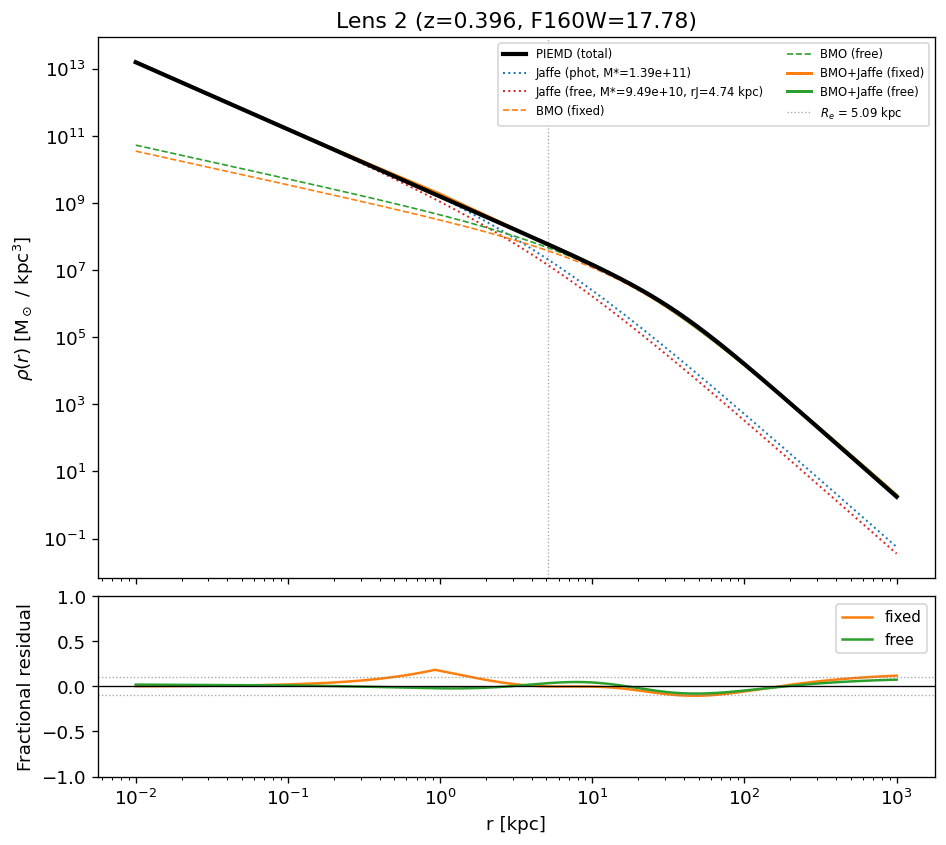

In [54]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

ax1.loglog(r, rho_piemd, "k-", lw=2.5, label="PIEMD (total)", zorder=5)
ax1.loglog(r, rho_jaffe_clamped, "C0:", lw=1.2, label=f"Jaffe (phot, M*={mstar_phot:.2e})")
ax1.loglog(r, rho_jaffe_free, "C3:", lw=1.2, label=f"Jaffe (free, M*={mstar_free:.2e}, rJ={rj_free:.2f} kpc)")
ax1.loglog(r, rho_dm_fix, "C1--", lw=1.0, label=f"{dm_label} (fixed)")
ax1.loglog(r, rho_dm_free, "C2--", lw=1.0, label=f"{dm_label} (free)")
ax1.loglog(r, rho_total_fix, "C1-", lw=1.8, label=f"{dm_label}+Jaffe (fixed)")
ax1.loglog(r, rho_total_free, "C2-", lw=1.8, label=f"{dm_label}+Jaffe (free)")
ax1.axvline(re, color="gray", ls=":", lw=0.8, alpha=0.7, label=f"$R_e$ = {re:.2f} kpc")
ax1.set_ylabel(r"$\rho(r)$ [M$_\odot$ / kpc$^3$]")
ax1.set_title(f"Lens {int(gal['lens_index'])} (z={gal['z_lens']:.3f}, F160W={gal['F160W']:.2f})")
ax1.legend(fontsize=7, ncol=2, loc="upper right")

pos = rho_piemd > 0
ax2.semilogx(r[pos], (rho_total_fix[pos]-rho_piemd[pos])/rho_piemd[pos], "C1-", lw=1.5, label="fixed")
ax2.semilogx(r[pos], (rho_total_free[pos]-rho_piemd[pos])/rho_piemd[pos], "C2-", lw=1.5, label="free")
ax2.axhline(0, color="k", lw=0.8)
ax2.axhline(0.1, color="gray", ls=":", lw=0.8, alpha=0.7)
ax2.axhline(-0.1, color="gray", ls=":", lw=0.8, alpha=0.7)
ax2.set_xlabel("r [kpc]"); ax2.set_ylabel("Fractional residual"); ax2.set_ylim(-1, 1)
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## 7. Error Estimation from MCMC Samples

### 7.1 Find the galaxy in the HDF5 file

In [55]:
lens_id = int(gal["lens_index"])
igal = int(np.where(h5_lens_idx == lens_id)[0][0])
print(f"Galaxy with lens_index={lens_id} is at HDF5 row {igal}")

Galaxy with lens_index=2 is at HDF5 row 2


### 7.2 Extract MCMC samples and filter valid ones

In [56]:
free_samp = free_params[igal]   # (N_samp, 4 or 5)
fix_samp  = fix_params[igal]    # (N_samp, 2 or 3)

valid_free = np.all(np.isfinite(free_samp), axis=1)
valid_fix  = np.all(np.isfinite(fix_samp), axis=1)

print(f"Valid free-fit samples: {valid_free.sum()} / {N_samp}")
print(f"Valid fixed-fit samples: {valid_fix.sum()} / {N_samp}")

Valid free-fit samples: 100 / 100
Valid fixed-fit samples: 100 / 100


### 7.3 Compute density profile envelopes

In [57]:
def compute_profiles_for_samples(r, samples, profile_type, re_kpc, mstar_phot, mode="free"):
    """Compute DM, Jaffe, and total density for each MCMC sample.

    Supports both new free-Jaffe format (explicit rJ) and legacy format (no rJ column).
    """
    N, Nr = len(samples), len(r)
    rho_dm = np.full((N, Nr), np.nan, dtype=float)
    rho_jaffe = np.full((N, Nr), np.nan, dtype=float)
    profile_type = str(profile_type).strip().lower()

    for i in range(N):
        p = samples[i]
        if profile_type == "tnfw":
            rho_dm[i] = trunc_nfw_rho(r, p[0], p[1], p[2])
        elif profile_type == "nfw":
            rho_dm[i] = nfw_rho(r, p[0], p[1])
        elif profile_type == "bmo":
            rho_dm[i] = bmo_rho(r, p[0], p[1], p[2])
        elif profile_type == "einasto":
            rho_dm[i] = einasto_rho(r, p[0], p[1], p[2])
        elif profile_type == "gnfw":
            rho_dm[i] = gnfw_rho(r, p[0], p[1], p[2])
        else:
            raise ValueError(f"Unsupported dm profile '{profile_type}' in section 7.3")

        has_rj = (profile_type == "nfw" and len(p) >= 4) or (profile_type != "nfw" and len(p) >= 5)
        if mode == "free":
            ms_idx = -2 if has_rj else -1
            ms = p[ms_idx]
            rj = p[-1] if has_rj else re_kpc
        else:
            ms = mstar_phot
            rj = re_kpc

        rho_jaffe[i] = jaffe_rho_rj(r, ms, rj)

    return rho_dm, rho_jaffe, rho_dm + rho_jaffe

In [58]:
r_plot = np.logspace(-2, 3, 300)

dm_free, jaffe_free_arr, total_free = compute_profiles_for_samples(
    r_plot, free_samp[valid_free], profile, re, mstar_phot, mode="free")
dm_fix_arr, jaffe_fix_arr, total_fix_arr = compute_profiles_for_samples(
    r_plot, fix_samp[valid_fix], profile, re, mstar_phot, mode="fix")

def pct(arr, q=[16, 50, 84]):
    arr = np.asarray(arr, dtype=float)
    if arr.ndim != 2:
        raise ValueError("Expected 2-D array of shape (N_samples, N_radii)")
    if arr.shape[0] == 0:
        return np.full((len(q), arr.shape[1]), np.nan, dtype=float)
    return np.nanpercentile(arr, q, axis=0)

free_total_pct = pct(total_free)
free_dm_pct    = pct(dm_free)
free_jaffe_pct = pct(jaffe_free_arr)
fix_total_pct  = pct(total_fix_arr)

print(f"Samples used in envelopes: free={total_free.shape[0]}, fix={total_fix_arr.shape[0]}")

Samples used in envelopes: free=100, fix=100


/var/folders/nh/wmnyr7p57hs85k47h_lx28mc0000gn/T/ipykernel_49391/4000188309.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


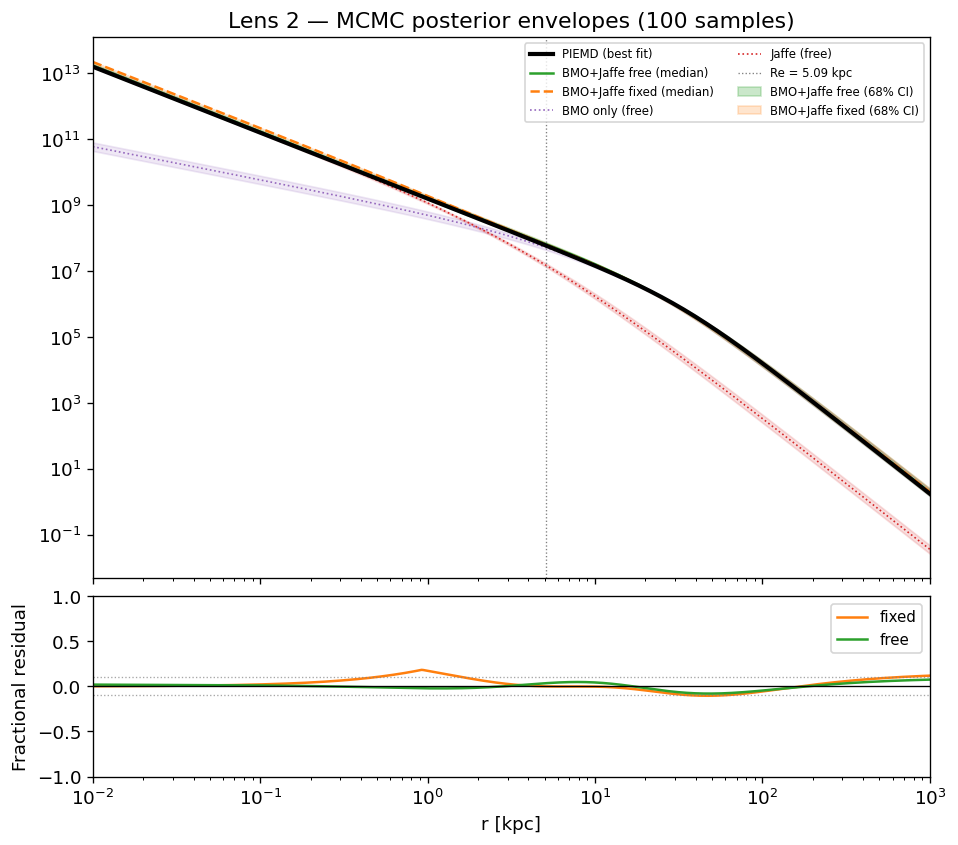

In [59]:
#fig, ax = plt.subplots(figsize=(9, 6))
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

ax.loglog(r_plot, piemd_rho(r_plot, gal["core_radius_kpc"],
          gal["cut_radius_kpc"], gal["v_disp_sigma0_km_s"]),
          "k-", lw=2.5, label="PIEMD (best fit)", zorder=5)

ax.fill_between(r_plot, free_total_pct[0], free_total_pct[2],
                alpha=0.25, color="C2", label=f"{dm_label}+Jaffe free (68% CI)")
ax.loglog(r_plot, free_total_pct[1], "C2-", lw=1.5, label=f"{dm_label}+Jaffe free (median)")

ax.fill_between(r_plot, fix_total_pct[0], fix_total_pct[2],
                alpha=0.2, color="C1", label=f"{dm_label}+Jaffe fixed (68% CI)")
ax.loglog(r_plot, fix_total_pct[1], "C1--", lw=1.5, label=f"{dm_label}+Jaffe fixed (median)")

ax.fill_between(r_plot, free_dm_pct[0], free_dm_pct[2], alpha=0.15, color="C4")
ax.loglog(r_plot, free_dm_pct[1], "C4:", lw=1.0, label=f"{dm_label} only (free)")

ax.fill_between(r_plot, free_jaffe_pct[0], free_jaffe_pct[2], alpha=0.15, color="C3")
ax.loglog(r_plot, free_jaffe_pct[1], "C3:", lw=1.0, label="Jaffe (free)")

ax.axvline(re, color="gray", ls=":", lw=0.8, label=f"Re = {re:.2f} kpc")

# Show the maximum fitting radius if set
rmax_fit = gal.get("rmax_fit_kpc", np.nan)
if np.isfinite(rmax_fit) and rmax_fit > 0:
    ax.axvline(rmax_fit, color="red", ls="--", lw=1.0, alpha=0.6,
               label=f"rmax_fit = {rmax_fit:.1f} kpc")

#ax.set_xlabel("r [kpc]"); ax.set_ylabel(r"$\rho(r)$ [M$_\odot$ / kpc$^3$]")
ax.set_title(f"Lens {lens_id} — MCMC posterior envelopes ({valid_free.sum()} samples)")
ax.set_xlim(r_plot[0], r_plot[-1])
ax.legend(fontsize=7, ncol=2, loc="upper right")

pos = rho_piemd > 0
ax2.semilogx(r[pos], (rho_total_fix[pos]-rho_piemd[pos])/rho_piemd[pos], "C1-", lw=1.5, label="fixed")
ax2.semilogx(r[pos], (rho_total_free[pos]-rho_piemd[pos])/rho_piemd[pos], "C2-", lw=1.5, label="free")
ax2.axhline(0, color="k", lw=0.8)
ax2.axhline(0.1, color="gray", ls=":", lw=0.8, alpha=0.7)
ax2.axhline(-0.1, color="gray", ls=":", lw=0.8, alpha=0.7)
ax2.set_xlabel("r [kpc]"); ax2.set_ylabel("Fractional residual"); ax2.set_ylim(-1, 1)
ax2.legend(fontsize=9)

plt.tight_layout(); plt.show()

### 7.4 Parameter posterior distributions

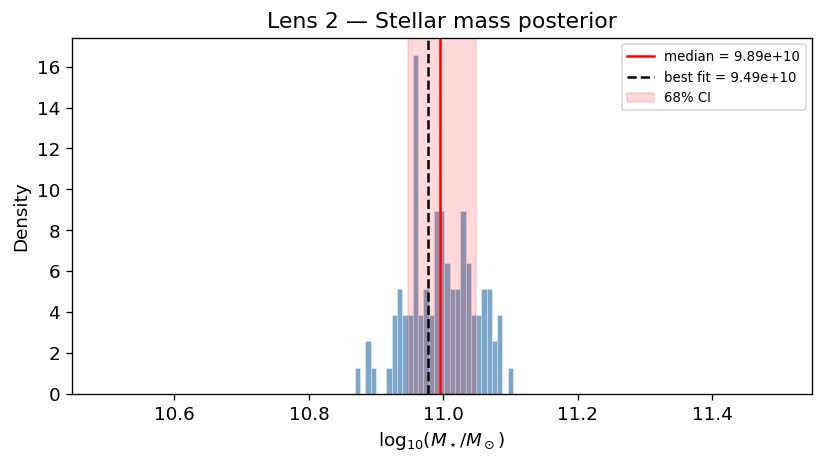

In [60]:
# NFW: mstar at index 2; others: mstar at index 3
mstar_idx = 2 if profile == "nfw" else 3
mstar_samples = free_samp[valid_free, mstar_idx]

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(mstar_samples), bins=30, density=True, alpha=0.7,
        color="steelblue", edgecolor="white", lw=0.3)
p16, p50, p84 = np.percentile(np.log10(mstar_samples), [16, 50, 84])
ax.axvline(p50, color="red", lw=1.5, label=f"median = {10**p50:.2e}")
ax.axvspan(p16, p84, alpha=0.15, color="red", label=f"68% CI")
ax.axvline(np.log10(mstar_free), color="k", ls="--", lw=1.5, label=f"best fit = {mstar_free:.2e}")
ax.set_xlabel(r"$\log_{10}(M_\star / M_\odot)$"); ax.set_ylabel("Density")
ax.set_title(f"Lens {lens_id} — Stellar mass posterior")
ax.set_xlim(p16-0.5, p84+0.5)
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

### 7.5 Diagnosing systematic offsets: best-fit vs MCMC median

A known subtlety: the **best-fit** DM parameters are computed from the
best-fit PIEMD parameters (from the `.par` file), while each MCMC sample
uses a *different* PIEMD target (from the scaling-relation chain). The MCMC
median therefore corresponds to the "typical" scaling-relation draw, which
need not coincide with the `.par` best fit.

If the best-fit is systematically offset from the MCMC median, it may
indicate:
- The `.par` best fit sits at a mode/tail of the scaling-relation posterior
- The warm-start initialisation introduces a directional bias
- Optimizer convergence issues for certain PIEMD targets

Below we check this for **all galaxies** and for the **individual galaxy**
selected above.

In [61]:
# --- Per-galaxy: best-fit vs MCMC median for the selected galaxy ---
print(f"=== Lens {lens_id}: best-fit vs MCMC p50 (free fit) ===\n")
print(f"{'Parameter':>20s}  {'Best-fit':>12s}  {'MCMC p50':>12s}  {'(bf-p50)/p50':>14s}")
print("-" * 65)

rj_bf = gal.get("rJ_free_kpc", np.nan)
if not np.isfinite(rj_bf) or rj_bf <= 0:
    rj_bf = gal["ReF160W_kpc"]

# Get best-fit values from CSV for the free fit
if profile == "tnfw":
    bf_free = [gal["rs_free_kpc"], gal["rt_free_kpc"], gal["rho0_free_msun_kpc3"], gal["Mstar_free_Msun"], rj_bf]
    plabels = ["rs (kpc)", "rt (kpc)", "rho0 (Msun/kpc3)", "M* (Msun)", "rJ (kpc)"]
elif profile == "nfw":
    bf_free = [gal["rs_nfw_free_kpc"], gal["rho0_nfw_free_msun_kpc3"], gal["Mstar_free_Msun"], rj_bf]
    plabels = ["rs (kpc)", "rho0 (Msun/kpc3)", "M* (Msun)", "rJ (kpc)"]
elif profile == "bmo":
    bf_free = [gal["rs_bmo_free_kpc"], gal["rt_bmo_free_kpc"], gal["rho0_bmo_free_msun_kpc3"], gal["Mstar_free_Msun"], rj_bf]
    plabels = ["rs (kpc)", "rt (kpc)", "rho0 (Msun/kpc3)", "M* (Msun)", "rJ (kpc)"]
elif profile == "einasto":
    bf_free = [gal["rs_ein_free_kpc"], gal["rhos_ein_free_msun_kpc3"], gal["n_ein_free"], gal["Mstar_free_Msun"], rj_bf]
    plabels = ["rs (kpc)", "rho_s (Msun/kpc3)", "n", "M* (Msun)", "rJ (kpc)"]
elif profile == "gnfw":
    bf_free = [gal["rs_gnfw_free_kpc"], gal["rhos_gnfw_free_msun_kpc3"], gal["gamma_gnfw_free"], gal["Mstar_free_Msun"], rj_bf]
    plabels = ["rs (kpc)", "rho_s (Msun/kpc3)", "gamma", "M* (Msun)", "rJ (kpc)"]

valid_samp = free_samp[valid_free]
ncols_compare = min(len(bf_free), valid_samp.shape[1])
for ip in range(ncols_compare):
    bf = bf_free[ip]
    med = np.nanmedian(valid_samp[:, ip])
    frac = (bf - med) / med if med != 0 else np.nan
    print(f"{plabels[ip]:>20s}  {bf:12.4e}  {med:12.4e}  {frac:+14.4f}")

if valid_samp.shape[1] < len(bf_free):
    print("\nNote: this HDF5 file uses legacy free-fit samples without explicit rJ column.")

=== Lens 2: best-fit vs MCMC p50 (free fit) ===

           Parameter      Best-fit      MCMC p50    (bf-p50)/p50
-----------------------------------------------------------------
            rs (kpc)    1.0561e+01    1.0422e+01         +0.0133
            rt (kpc)    3.2022e+01    3.1642e+01         +0.0120
    rho0 (Msun/kpc3)    5.0131e+07    5.6714e+07         -0.1161
           M* (Msun)    9.4876e+10    9.8933e+10         -0.0410
            rJ (kpc)    4.7376e+00    4.6707e+00         +0.0143


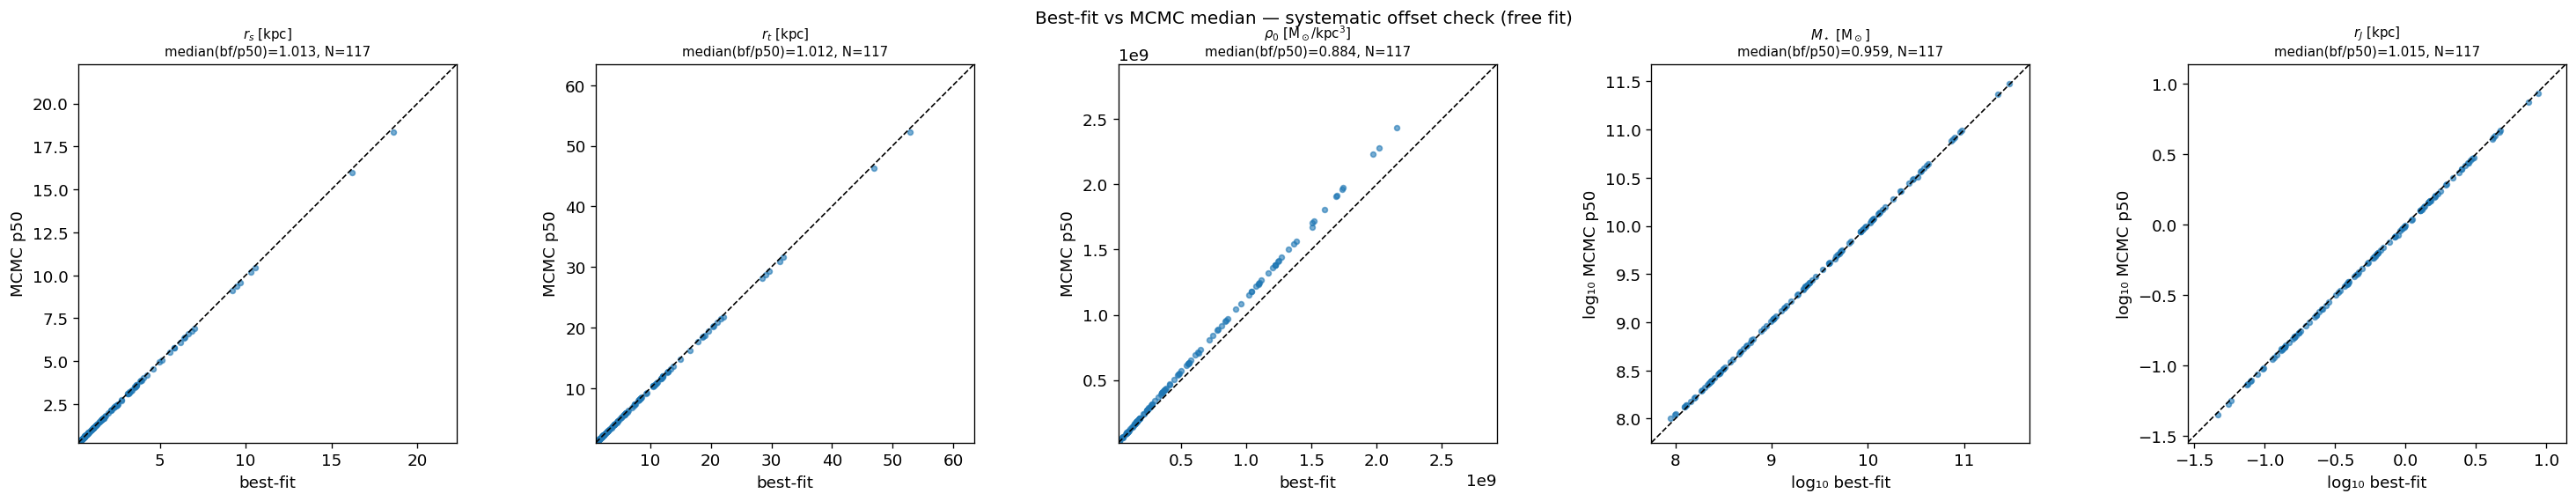


Aggregate bias summary (best-fit / MCMC p50):
                Parameter  median ratio    mean ratio       std  N
---------------------------------------------------------------------------
              $r_s$ [kpc]        1.0130        1.0128    0.0016  117
              $r_t$ [kpc]        1.0121        1.0123    0.0011  117
$\rho_0$ [M$_\odot$/kpc$^3$]        0.8838        0.8844    0.0031  117
    $M_\star$ [M$_\odot$]        0.9590        0.9569    0.0136  117
              $r_J$ [kpc]        1.0154        1.0175    0.0060  117


In [62]:
# --- Aggregate: best-fit vs MCMC p50 across ALL galaxies ---
# Compare the best-fit parameter to the MCMC p50 column from the CSV.

has_mcmc = "mcmc_nsamp_total" in df.columns
if not has_mcmc:
    print("No MCMC columns found in CSV — skipping aggregate check.")
else:
    converged_both = df["fit_free_success"].astype(bool)

    if profile == "tnfw":
        pairs = [
            ("rs_free_kpc",        "rs_free_p50",    r"$r_s$ [kpc]"),
            ("rt_free_kpc",        "rt_free_p50",    r"$r_t$ [kpc]"),
            ("rho0_free_msun_kpc3","rho0_free_p50",  r"$\rho_0$ [M$_\odot$/kpc$^3$]"),
            ("Mstar_free_Msun",    "Mstar_free_p50", r"$M_\star$ [M$_\odot$]"),
            ("rJ_free_kpc",        "rJ_free_p50",    r"$r_J$ [kpc]"),
        ]
    elif profile == "nfw":
        pairs = [
            ("rs_nfw_free_kpc",          "rs_nfw_free_p50",    r"$r_s$ [kpc]"),
            ("rho0_nfw_free_msun_kpc3",  "rho0_nfw_free_p50",  r"$\rho_0$ [M$_\odot$/kpc$^3$]"),
            ("Mstar_free_Msun",          "Mstar_free_p50",     r"$M_\star$ [M$_\odot$]"),
            ("rJ_free_kpc",              "rJ_free_p50",        r"$r_J$ [kpc]"),
        ]
    elif profile == "bmo":
        pairs = [
            ("rs_bmo_free_kpc",          "rs_bmo_free_p50",    r"$r_s$ [kpc]"),
            ("rt_bmo_free_kpc",          "rt_bmo_free_p50",    r"$r_t$ [kpc]"),
            ("rho0_bmo_free_msun_kpc3",  "rho0_bmo_free_p50",  r"$\rho_0$ [M$_\odot$/kpc$^3$]"),
            ("Mstar_free_Msun",          "Mstar_free_p50",     r"$M_\star$ [M$_\odot$]"),
            ("rJ_free_kpc",              "rJ_free_p50",        r"$r_J$ [kpc]"),
        ]
    elif profile == "einasto":
        pairs = [
            ("rs_ein_free_kpc",          "rs_ein_free_p50",    r"$r_s$ [kpc]"),
            ("rhos_ein_free_msun_kpc3",  "rhos_ein_free_p50",  r"$\rho_s$ [M$_\odot$/kpc$^3$]"),
            ("n_ein_free",               "n_ein_free_p50",     r"$n$"),
            ("Mstar_free_Msun",          "Mstar_free_p50",     r"$M_\star$ [M$_\odot$]"),
            ("rJ_free_kpc",              "rJ_free_p50",        r"$r_J$ [kpc]"),
        ]
    elif profile == "gnfw":
        pairs = [
            ("rs_gnfw_free_kpc",          "rs_gnfw_free_p50",    r"$r_s$ [kpc]"),
            ("rhos_gnfw_free_msun_kpc3",  "rhos_gnfw_free_p50",  r"$\rho_s$ [M$_\odot$/kpc$^3$]"),
            ("gamma_gnfw_free",           "gamma_gnfw_free_p50", r"$\gamma$"),
            ("Mstar_free_Msun",           "Mstar_free_p50",      r"$M_\star$ [M$_\odot$]"),
            ("rJ_free_kpc",               "rJ_free_p50",         r"$r_J$ [kpc]"),
        ]

    pairs = [p for p in pairs if p[0] in df.columns and p[1] in df.columns]
    if len(pairs) == 0:
        print("No matching best-fit vs MCMC p50 column pairs found.")
    else:
        n_panels = len(pairs)
        fig, axes = plt.subplots(1, n_panels, figsize=(5*n_panels, 4.5), constrained_layout=True)
        if n_panels == 1:
            axes = [axes]

        for ax, (bf_col, p50_col, label) in zip(axes, pairs):
            sub = df.loc[converged_both].dropna(subset=[bf_col, p50_col])
            x = sub[bf_col].values
            y = sub[p50_col].values
            ok = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
            if ok.sum() == 0:
                ax.set_title(f"{label}\n(no valid data)")
                continue

            use_log = (x[ok].max() / x[ok].min() > 100)
            if use_log:
                ax.scatter(np.log10(x[ok]), np.log10(y[ok]), s=12, alpha=0.6)
                lims = [min(np.log10(x[ok]).min(), np.log10(y[ok]).min()) - 0.2,
                        max(np.log10(x[ok]).max(), np.log10(y[ok]).max()) + 0.2]
                ax.plot(lims, lims, "k--", lw=1)
                ax.set_xlim(lims); ax.set_ylim(lims)
                ax.set_xlabel("log₁₀ best-fit")
                ax.set_ylabel("log₁₀ MCMC p50")
            else:
                ax.scatter(x[ok], y[ok], s=12, alpha=0.6)
                lims = [min(x[ok].min(), y[ok].min()) * 0.8, max(x[ok].max(), y[ok].max()) * 1.2]
                ax.plot(lims, lims, "k--", lw=1)
                ax.set_xlim(lims); ax.set_ylim(lims)
                ax.set_xlabel("best-fit")
                ax.set_ylabel("MCMC p50")

            ratio = x[ok] / y[ok]
            med_ratio = np.median(ratio)
            ax.set_title(f"{label}\nmedian(bf/p50)={med_ratio:.3f}, N={ok.sum()}", fontsize=9)
            ax.set_aspect("equal", adjustable="box")

        fig.suptitle("Best-fit vs MCMC median — systematic offset check (free fit)", fontsize=12, y=1.02)
        plt.show()

        print("\nAggregate bias summary (best-fit / MCMC p50):")
        print(f"{'Parameter':>25s}  {'median ratio':>12s}  {'mean ratio':>12s}  {'std':>8s}  N")
        print("-" * 75)
        for bf_col, p50_col, label in pairs:
            sub = df.loc[converged_both].dropna(subset=[bf_col, p50_col])
            x = sub[bf_col].values
            y = sub[p50_col].values
            ok = np.isfinite(x) & np.isfinite(y) & (y > 0)
            if ok.sum() == 0:
                continue
            ratio = x[ok] / y[ok]
            print(f"{label:>25s}  {np.median(ratio):12.4f}  {np.mean(ratio):12.4f}  {np.std(ratio):8.4f}  {ok.sum()}")

---
## 8. Derived Quantities: $c_{200}$, $R_{200}$, $M_{200}$

### 8.1 From CSV

In [63]:
if profile == "tnfw":
    for mode in ["fix", "free"]:
        print(f"--- {mode} fit ---")
        print(f"  c200 = {gal.get(f'c200_{mode}', 'N/A'):.1f}")
        if mode == "fix":
            print(f"  R200 = {gal.get('R200_fix_kpc', 'N/A'):.1f} kpc")
            print(f"  M200 = {gal.get('M200_fix_Msun', 'N/A'):.3e} Msun")
        else:
            print(f"  R200 = {gal.get('R200_free_kpc', 'N/A'):.1f} kpc")
            print(f"  M200 = {gal.get('M200_free_Msun', 'N/A'):.3e} Msun")
elif profile == "nfw":
    for mode in ["fix", "free"]:
        print(f"--- {mode} fit ---")
        print(f"  c200 = {gal.get(f'c200_{mode}', 'N/A')}")
        print(f"  R200 = {gal.get(f'R200_nfw_{mode}_kpc', 'N/A')} kpc")
        print(f"  M200 = {gal.get(f'M200_nfw_{mode}_Msun', 'N/A')} Msun")
elif profile == "bmo":
    for mode in ["fix", "free"]:
        print(f"--- {mode} fit ---")
        print(f"  c200 = {gal.get(f'c200_{mode}', 'N/A')}")
        print(f"  R200 = {gal.get(f'R200_bmo_{mode}_kpc', 'N/A')} kpc")
        print(f"  M200 = {gal.get(f'M200_bmo_{mode}_Msun', 'N/A')} Msun")
elif profile == "einasto":
    for mode in ["fix", "free"]:
        print(f"--- {mode} fit ---")
        print(f"  c200 = {gal.get(f'c200_{mode}', 'N/A')}")
        print(f"  R200 = {gal.get(f'R200_ein_{mode}_kpc', 'N/A')} kpc")
        print(f"  M200 = {gal.get(f'M200_ein_{mode}_Msun', 'N/A')} Msun")
elif profile == "gnfw":
    for mode in ["fix", "free"]:
        print(f"--- {mode} fit ---")
        print(f"  c200 = {gal.get(f'c200_{mode}', 'N/A')}")
        print(f"  R200 = {gal.get(f'R200_gnfw_{mode}_kpc', 'N/A')} kpc")
        print(f"  M200 = {gal.get(f'M200_gnfw_{mode}_Msun', 'N/A')} Msun")

--- fix fit ---
  c200 = 10.546811538675293
  R200 = 161.48458212664752 kpc
  M200 = 727399578413.1357 Msun
--- free fit ---
  c200 = 15.687333651023772
  R200 = 165.67474564810485 kpc
  M200 = 785498630160.8713 Msun


### 8.2 Computing $c_{200}$, $M_{200}$ from MCMC samples

In [64]:
from astropy.cosmology import FlatLambdaCDM
from scipy.optimize import brentq

cosmo = FlatLambdaCDM(H0=70.0, Om0=0.3)
z_lens = gal["z_lens"]
rho_crit = cosmo.critical_density(z_lens).to_value("Msun/kpc3")
print(f"rho_crit(z={z_lens:.3f}) = {rho_crit:.4e} Msun/kpc^3")

rho_crit(z=0.396) = 2.0619e+02 Msun/kpc^3


In [65]:
def c200_from_tnfw(rs, rho0, rho_crit):
    """Solve (200/3)*c^3/[ln(1+c)-c/(1+c)] = rho0/rho_crit."""
    S = rho0 / rho_crit
    try:
        return brentq(lambda c: (200/3)*c**3/(np.log1p(c)-c/(1+c)) - S, 1e-6, 1e5)
    except:
        return np.nan

def M_tNFW_enclosed(r, rs, rt, rho0):
    """Enclosed mass of the truncated NFW (closed-form)."""
    x, tau = r/rs, rt/rs
    tau2 = tau**2; denom = (tau2+1)**2
    A = tau2*(tau2-1)/denom; B = -tau2/(tau2+1); D = 2*tau2**2/denom
    return 4*np.pi*rho0*rs**3*(A*(np.log1p(x)-0.5*np.log1p((x/tau)**2)) + B*x/(1+x) + (D/tau)*np.arctan(x/tau))

def M_NFW_enclosed(r, rs, rho0):
    """Enclosed mass of the standard NFW (closed-form)."""
    x = r / rs
    return 4.0 * np.pi * rho0 * rs**3 * (np.log1p(x) - x / (1.0 + x))

def M_BMO_enclosed(r, rs, rt, rho0):
    """Enclosed mass of the BMO (n=0.5) profile (numerical integration)."""
    rg = np.linspace(1e-6, r, 5000)
    rhog = bmo_rho(rg, rs, rt, rho0)
    integ = 4 * np.pi * rg**2 * rhog
    return float(np.trapz(integ, rg))

def derived_from_sample(sample, profile_type, rho_crit):
    """Compute c200, R200, M200 from one MCMC sample (DM params only)."""
    result = {"c200": np.nan, "R200_kpc": np.nan, "M200_Msun": np.nan}
    rs = sample[0]
    if profile_type == "tnfw":
        rt, rho0 = sample[1], sample[2]
        c200 = c200_from_tnfw(rs, rho0, rho_crit)
        if np.isfinite(c200):
            R200 = c200 * rs
            result.update(c200=c200, R200_kpc=R200, M200_Msun=float(M_tNFW_enclosed(R200, rs, rt, rho0)))
    elif profile_type == "nfw":
        rho0 = sample[1]
        c200 = c200_from_tnfw(rs, rho0, rho_crit)  # same c200 relation for NFW
        if np.isfinite(c200):
            R200 = c200 * rs
            result.update(c200=c200, R200_kpc=R200, M200_Msun=float(M_NFW_enclosed(R200, rs, rho0)))
    elif profile_type == "bmo":
        rt, rho0 = sample[1], sample[2]
        c200 = c200_from_tnfw(rs, rho0, rho_crit)  # same c200 relation (based on central rho0)
        if np.isfinite(c200):
            R200 = c200 * rs
            result.update(c200=c200, R200_kpc=R200, M200_Msun=float(M_BMO_enclosed(R200, rs, rt, rho0)))
    else:
        rho_s, sp = sample[1], sample[2]
        rg = np.linspace(1e-4, 5000, 10000)
        rhog = einasto_rho(rg, rs, rho_s, sp) if profile_type == "einasto" else gnfw_rho(rg, rs, rho_s, sp)
        integ = 4*np.pi*rg**2*rhog
        Mg = np.zeros_like(rg); Mg[1:] = np.cumsum(0.5*(integ[1:]+integ[:-1])*np.diff(rg))
        mean_rho = Mg / ((4/3)*np.pi*rg**3)
        above = mean_rho >= 200*rho_crit
        if np.any(above):
            idx = np.where(above)[0][-1]
            if idx < len(rg)-1:
                r1, r2 = rg[idx], rg[idx+1]
                d1, d2 = mean_rho[idx]-200*rho_crit, mean_rho[idx+1]-200*rho_crit
                R200 = r1 - d1*(r2-r1)/(d2-d1)
                result.update(c200=R200/rs, R200_kpc=float(R200), M200_Msun=float(np.interp(R200, rg, Mg)))
    return result

In [66]:
valid_samples = free_samp[valid_free]
c200_arr = np.array([derived_from_sample(s, profile, rho_crit)["c200"] for s in valid_samples])
m200_arr = np.array([derived_from_sample(s, profile, rho_crit)["M200_Msun"] for s in valid_samples])

ok = np.isfinite(c200_arr) & np.isfinite(m200_arr)
print(f"Valid c200/M200 for {ok.sum()}/{len(valid_samples)} samples")
if ok.sum() > 0:
    p16, p50, p84 = np.percentile(c200_arr[ok], [16, 50, 84])
    print(f"c200: median={p50:.1f}, 68% CI=[{p16:.1f}, {p84:.1f}]")
    p16, p50, p84 = np.percentile(np.log10(m200_arr[ok]), [16, 50, 84])
    print(f"log10(M200/Msun): median={p50:.2f}, 68% CI=[{p16:.2f}, {p84:.2f}]")

Valid c200/M200 for 100/100 samples
c200: median=20.6, 68% CI=[17.0, 25.0]
log10(M200/Msun): median=11.94, 68% CI=[11.89, 11.97]


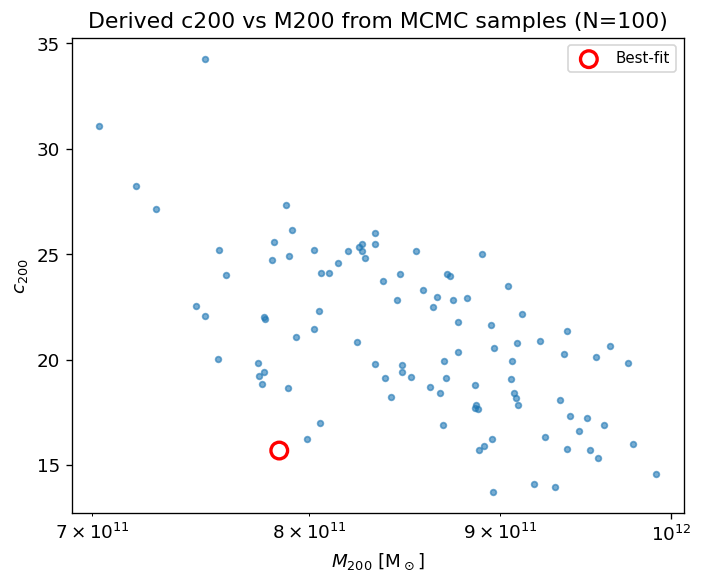

In [67]:
# plot c200 vs M200 for the valid samples
fig, ax = plt.subplots(figsize=(6, 5))
ok = np.isfinite(c200_arr) & np.isfinite(m200_arr)
ax.scatter(m200_arr[ok], c200_arr[ok], s=12, alpha=0.6)
ax.set_xscale("log")
ax.set_xlabel(r"$M_{200}$ [M$_\odot$]")
ax.set_ylabel(r"$c_{200}$")
ax.set_title(f"Derived c200 vs M200 from MCMC samples (N={ok.sum()})")
# mark positions of best-fit values if available
if profile == "tnfw":
    bf_c200 = gal.get("c200_free", np.nan)
    bf_m200 = gal.get("M200_free_Msun", np.nan)
elif profile == "nfw":
    bf_c200 = gal.get("c200_free", np.nan)
    bf_m200 = gal.get("M200_nfw_free_Msun", np.nan)
elif profile == "bmo":
    bf_c200 = gal.get("c200_free", np.nan)
    bf_m200 = gal.get("M200_bmo_free_Msun", np.nan)
elif profile == "einasto":
    bf_c200 = gal.get("c200_free", np.nan)
    bf_m200 = gal.get("M200_ein_free_Msun", np.nan)
elif profile == "gnfw":
    bf_c200 = gal.get("c200_free", np.nan)
    bf_m200 = gal.get("M200_gnfw_free_Msun", np.nan)
if np.isfinite(bf_c200) and np.isfinite(bf_m200):
    ax.scatter(bf_m200, bf_c200, s=100, edgecolor="red", facecolor="none", lw=2, label="Best-fit")
    ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## 9. Batch Processing: Looping Over All Galaxies

In [68]:
r_eval = np.logspace(-1, 2.5, 200)
converged = df["fit_free_success"].astype(bool)
print(f"Processing {converged.sum()} converged galaxies...\n")

for _, row in df.loc[converged].head(5).iterrows():
    lid = int(row["lens_index"])
    prof = str(row["dm_profile"]).strip().lower()
    re_i = row["ReF160W_kpc"]
    rj_i = row.get("rJ_free_kpc", np.nan)
    if not np.isfinite(rj_i) or rj_i <= 0:
        rj_i = re_i
    rho_p = piemd_rho(r_eval, row["core_radius_kpc"], row["cut_radius_kpc"], row["v_disp_sigma0_km_s"])
    if prof == "tnfw":
        rho_d = trunc_nfw_rho(r_eval, row["rs_free_kpc"], row["rt_free_kpc"], row["rho0_free_msun_kpc3"])
    elif prof == "nfw":
        rho_d = nfw_rho(r_eval, row["rs_nfw_free_kpc"], row["rho0_nfw_free_msun_kpc3"])
    elif prof == "bmo":
        rho_d = bmo_rho(r_eval, row["rs_bmo_free_kpc"], row["rt_bmo_free_kpc"], row["rho0_bmo_free_msun_kpc3"])
    elif prof == "einasto":
        rho_d = einasto_rho(r_eval, row["rs_ein_free_kpc"], row["rhos_ein_free_msun_kpc3"], row["n_ein_free"])
    elif prof == "gnfw":
        rho_d = gnfw_rho(r_eval, row["rs_gnfw_free_kpc"], row["rhos_gnfw_free_msun_kpc3"], row["gamma_gnfw_free"])
    rho_j = jaffe_rho_rj(r_eval, row["Mstar_free_Msun"], rj_i)
    m = rho_p > 0
    med_res = np.median(np.abs((rho_d+rho_j)[m] - rho_p[m]) / rho_p[m])
    print(f"Lens {lid:4d} | z={row['z_lens']:.3f} | F160W={row['F160W']:5.2f} | median |drho/rho| = {med_res:.4f}")

Processing 117 converged galaxies...

Lens    0 | z=0.396 | F160W=17.34 | median |drho/rho| = 0.0163
Lens    1 | z=0.396 | F160W=17.53 | median |drho/rho| = 0.0174
Lens    2 | z=0.396 | F160W=17.78 | median |drho/rho| = 0.0201
Lens    3 | z=0.396 | F160W=17.79 | median |drho/rho| = 0.0203
Lens    4 | z=0.396 | F160W=18.02 | median |drho/rho| = 0.0207


---
## 9.1 Stellar Mass Comparison: Photometry vs Free-Jaffe Fit

The free-Jaffe fitting mode treats $M_\star$ as a free parameter, so
the recovered stellar mass can differ from the photometric estimate.
Below we compare the two for all converged galaxies.

In [69]:
mask_mstar = (
    df["fit_free_success"].astype(bool)
    & np.isfinite(df["Mstar_from_F160W_Msun"])
    & np.isfinite(df["Mstar_free_Msun"])
    & (df["Mstar_from_F160W_Msun"] > 0)
    & (df["Mstar_free_Msun"] > 0)
)
df_ms = df.loc[mask_mstar].copy()
log_phot = np.log10(df_ms["Mstar_from_F160W_Msun"].values)
log_free = np.log10(df_ms["Mstar_free_Msun"].values)

print(f"Galaxies with valid M* comparison: {len(df_ms)}")
ratio = df_ms["Mstar_free_Msun"].values / df_ms["Mstar_from_F160W_Msun"].values
print(f"M*_free / M*_phot — median: {np.median(ratio):.3f}, "
      f"mean: {np.mean(ratio):.3f}, std: {np.std(ratio):.3f}")
print(f"log10 offset — median: {np.median(log_free - log_phot):.3f}, "
      f"scatter (MAD): {np.median(np.abs(log_free - log_phot - np.median(log_free - log_phot))):.3f}")

Galaxies with valid M* comparison: 117
M*_free / M*_phot — median: 0.384, mean: 0.466, std: 0.346
log10 offset — median: -0.416, scatter (MAD): 0.149


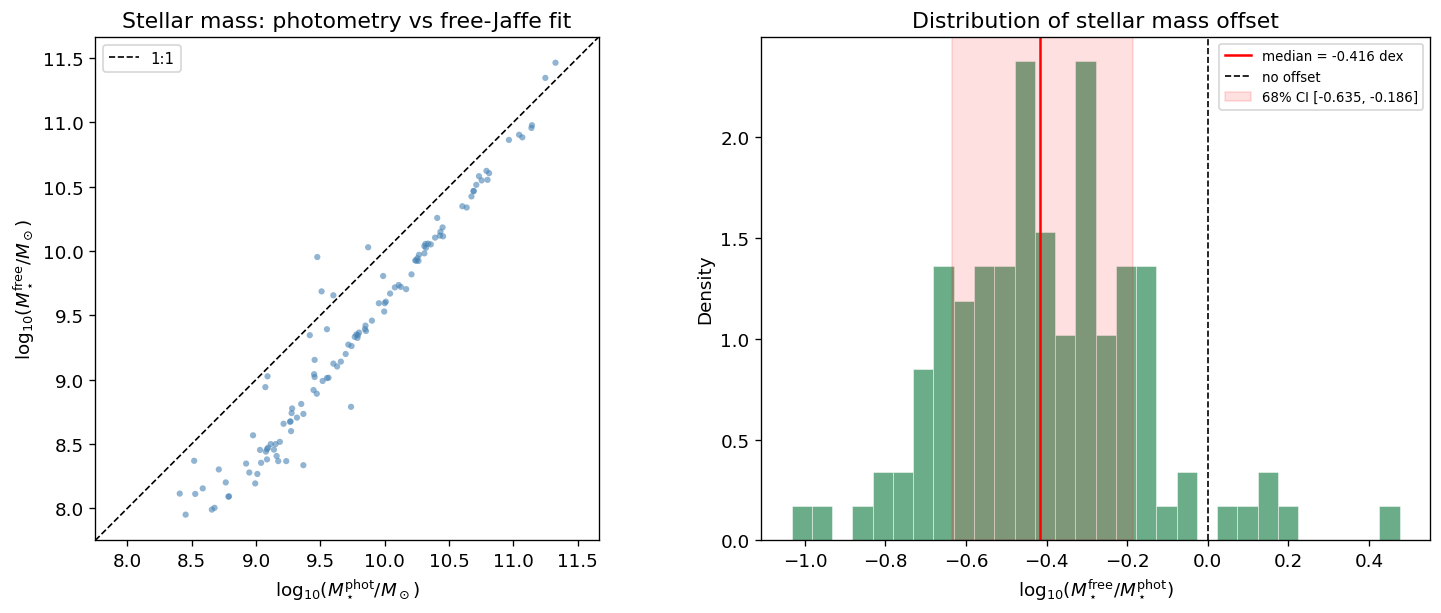

In [70]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

# --- Scatter plot ---
ax1.scatter(log_phot, log_free, s=14, alpha=0.6, edgecolors="none", c="steelblue")
lims = [min(log_phot.min(), log_free.min()) - 0.2,
        max(log_phot.max(), log_free.max()) + 0.2]
ax1.plot(lims, lims, "k--", lw=1.0, label="1:1")
ax1.set_xlim(lims); ax1.set_ylim(lims)
ax1.set_xlabel(r"$\log_{10}(M_\star^{\rm phot} / M_\odot)$")
ax1.set_ylabel(r"$\log_{10}(M_\star^{\rm free} / M_\odot)$")
ax1.set_title("Stellar mass: photometry vs free-Jaffe fit")
ax1.set_aspect("equal", adjustable="box")
ax1.legend(fontsize=9)

# --- Histogram of log ratio ---
dlog = log_free - log_phot
ax2.hist(dlog, bins=30, density=True, alpha=0.7, color="seagreen",
         edgecolor="white", lw=0.4)
med_dlog = np.median(dlog)
ax2.axvline(med_dlog, color="red", lw=1.5,
            label=f"median = {med_dlog:+.3f} dex")
ax2.axvline(0, color="k", lw=1.0, ls="--", label="no offset")
p16, p84 = np.percentile(dlog, [16, 84])
ax2.axvspan(p16, p84, alpha=0.12, color="red",
            label=f"68% CI [{p16:+.3f}, {p84:+.3f}]")
ax2.set_xlabel(r"$\log_{10}(M_\star^{\rm free} / M_\star^{\rm phot})$")
ax2.set_ylabel("Density")
ax2.set_title("Distribution of stellar mass offset")
ax2.legend(fontsize=8)

plt.show()

---
## 9.2 Concentration–Mass Relation (Free Fit)

This section shows the free-fit $c_{200}$–$M_{200}$ relation, compares it to an LCDM expectation,
identifies outliers, and fits a robust power-law relation:

$$c_{200}(M) = c_0 \left(\frac{M_{200}}{M_{\rm piv}}\right)^\beta$$

or equivalently in log-space:

$$\log_{10} c_{200} = a + \beta\,\left[\log_{10}(M_{200})-\log_{10}(M_{\rm piv})\right],\quad c_0=10^a.$$

In [71]:
from scipy.optimize import least_squares

# --- profile-aware M200 column for FREE mode ---
profile_all = str(df["dm_profile"].dropna().iloc[0]).strip().lower() if "dm_profile" in df.columns else "tnfw"
if profile_all == "tnfw":
    m_col_free = "M200_free_Msun"
elif profile_all == "nfw":
    m_col_free = "M200_nfw_free_Msun"
elif profile_all == "bmo":
    m_col_free = "M200_bmo_free_Msun"
elif profile_all == "einasto":
    m_col_free = "M200_ein_free_Msun"
elif profile_all == "gnfw":
    m_col_free = "M200_gnfw_free_Msun"
else:
    raise ValueError(f"Unknown dm_profile: {profile_all}")

c_col_free = "c200_free"

# Optional percentile columns for error bars
m_p16_col, m_p50_col, m_p84_col = "M200_free_p16", "M200_free_p50", "M200_free_p84"
c_p16_col, c_p50_col, c_p84_col = "c200_free_p16", "c200_free_p50", "c200_free_p84"

needed = ["lens_index", "z_lens", m_col_free, c_col_free]
for col in [m_p16_col, m_p50_col, m_p84_col, c_p16_col, c_p50_col, c_p84_col]:
    if col in df.columns:
        needed.append(col)

ok = (
    df["fit_free_success"].astype(bool)
    & np.isfinite(df[m_col_free]) & (df[m_col_free] > 0)
    & np.isfinite(df[c_col_free]) & (df[c_col_free] > 0)
)
cm = df.loc[ok, needed].copy()
cm = cm.rename(columns={m_col_free: "M200_best", c_col_free: "c200_best"})

# Plot centers: use p50 if available, else best-fit
has_m_p = all(col in cm.columns for col in [m_p16_col, m_p50_col, m_p84_col])
has_c_p = all(col in cm.columns for col in [c_p16_col, c_p50_col, c_p84_col])

if has_m_p:
    m_center = cm[m_p50_col].values.copy()
    m_center[~np.isfinite(m_center) | (m_center <= 0)] = cm["M200_best"].values[~np.isfinite(m_center) | (m_center <= 0)]
else:
    m_center = cm["M200_best"].values

if has_c_p:
    c_center = cm[c_p50_col].values.copy()
    c_center[~np.isfinite(c_center) | (c_center <= 0)] = cm["c200_best"].values[~np.isfinite(c_center) | (c_center <= 0)]
else:
    c_center = cm["c200_best"].values

cm["M200"] = m_center
cm["c200"] = c_center

x = np.log10(cm["M200"].values)
y = np.log10(cm["c200"].values)

# Build error bars if percentile columns exist
cm["xerr_lo"] = np.nan
cm["xerr_hi"] = np.nan
cm["yerr_lo"] = np.nan
cm["yerr_hi"] = np.nan

if has_m_p:
    m16 = cm[m_p16_col].values
    m84 = cm[m_p84_col].values
    good_m = np.isfinite(m16) & np.isfinite(m84) & (m16 > 0) & (m84 > 0) & (m84 >= m16)
    xerr_lo = np.full(len(cm), np.nan)
    xerr_hi = np.full(len(cm), np.nan)
    xerr_lo[good_m] = np.log10(cm.loc[good_m, "M200"].values) - np.log10(m16[good_m])
    xerr_hi[good_m] = np.log10(m84[good_m]) - np.log10(cm.loc[good_m, "M200"].values)
    cm["xerr_lo"] = np.clip(xerr_lo, 0, None)
    cm["xerr_hi"] = np.clip(xerr_hi, 0, None)

if has_c_p:
    c16 = cm[c_p16_col].values
    c84 = cm[c_p84_col].values
    good_c = np.isfinite(c16) & np.isfinite(c84) & (c16 > 0) & (c84 > 0) & (c84 >= c16)
    yerr_lo = np.full(len(cm), np.nan)
    yerr_hi = np.full(len(cm), np.nan)
    yerr_lo[good_c] = cm.loc[good_c, "c200"].values - c16[good_c]
    yerr_hi[good_c] = c84[good_c] - cm.loc[good_c, "c200"].values
    cm["yerr_lo"] = np.clip(yerr_lo, 0, None)
    cm["yerr_hi"] = np.clip(yerr_hi, 0, None)

# Pivot mass for stable fit parameterization
x_piv = np.median(x)
M_piv = 10**x_piv

# --- robust fit: log10(c) = a + beta*(x - x_piv) ---
def resid(theta, x_, y_):
    a, beta = theta
    return y_ - (a + beta * (x_ - x_piv))

theta0 = np.array([np.median(y), -0.1])
sol = least_squares(resid, theta0, loss="soft_l1", f_scale=0.05, args=(x, y))
a_hat, beta_hat = sol.x

y_fit = a_hat + beta_hat * (x - x_piv)
r = y - y_fit
med_r = np.median(r)
mad_r = np.median(np.abs(r - med_r))
sig_r = 1.4826 * mad_r if mad_r > 0 else np.std(r)
sig_r = max(sig_r, 0.02)

# Outliers relative to robust relation
out_mask = np.abs(r - med_r) > 3.0 * sig_r
cm["is_outlier"] = out_mask
cm["residual_dex"] = r
cm["residual_sigma"] = np.abs((r - med_r) / sig_r)

# --- LCDM expectation: Dutton & Maccio 2014 (Planck), c200(M200,z) ---
def c200_lcdm_dm14(m200_msun, z, h=0.7):
    z = max(float(z), 0.0)
    a = 0.520 + (0.905 - 0.520) * np.exp(-0.617 * (z**1.21))
    b = -0.101 + 0.026 * z
    xh = np.log10((np.asarray(m200_msun) * h) / 1.0e12)
    return 10.0 ** (a + b * xh)

z_ref = float(np.nanmedian(cm["z_lens"].values)) if "z_lens" in cm.columns else 0.4

# --- bootstrap error band for robust fit ---
rng = np.random.default_rng(42)
nb = 400
x_grid = np.linspace(x.min(), x.max(), 250)
Yb = np.full((nb, len(x_grid)), np.nan)

for ib in range(nb):
    ii = rng.integers(0, len(x), len(x))
    xb, yb = x[ii], y[ii]
    t0 = np.array([np.median(yb), beta_hat])
    sb = least_squares(resid, t0, loss="soft_l1", f_scale=0.05, args=(xb, yb))
    a_b, b_b = sb.x
    Yb[ib] = a_b + b_b * (x_grid - x_piv)

fit_med = np.nanmedian(Yb, axis=0)
fit_lo = np.nanpercentile(Yb, 16, axis=0)
fit_hi = np.nanpercentile(Yb, 84, axis=0)

c0_hat = 10**a_hat
n_err = np.isfinite(cm["xerr_lo"]) & np.isfinite(cm["xerr_hi"]) & np.isfinite(cm["yerr_lo"]) & np.isfinite(cm["yerr_hi"])
print(f"Profile type: {profile_all}")
print(f"N galaxies (free fit): {len(cm)}")
print(f"Points with both x/y error bars: {n_err.sum()}")
print(f"Robust fit: c0={c0_hat:.2f} at M_piv={M_piv:.3e} Msun, beta={beta_hat:.3f}")
print(f"Robust scatter (dex): {sig_r:.3f}")
print(f"Outliers (>3σ): {out_mask.sum()}")

Profile type: bmo
N galaxies (free fit): 117
Points with both x/y error bars: 117
Robust fit: c0=33.40 at M_piv=2.681e+10 Msun, beta=-0.199
Robust scatter (dex): 0.020
Outliers (>3σ): 2


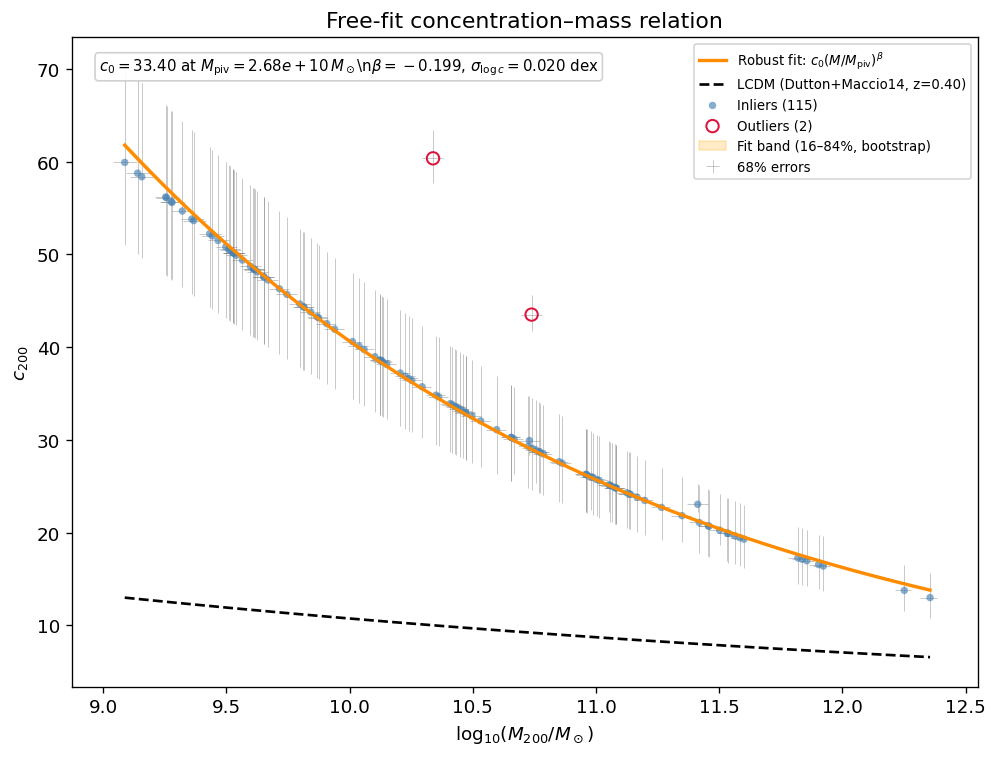

In [72]:
fig, ax = plt.subplots(figsize=(8.2, 6.2), constrained_layout=True)

inl = ~cm["is_outlier"].values
outl = cm["is_outlier"].values

# Error bars (if available)
has_err = np.isfinite(cm["xerr_lo"]) & np.isfinite(cm["xerr_hi"]) & np.isfinite(cm["yerr_lo"]) & np.isfinite(cm["yerr_hi"])
if has_err.sum() > 0:
    xerr = np.vstack([cm.loc[has_err, "xerr_lo"].values, cm.loc[has_err, "xerr_hi"].values])
    yerr = np.vstack([cm.loc[has_err, "yerr_lo"].values, cm.loc[has_err, "yerr_hi"].values])
    ax.errorbar(np.log10(cm.loc[has_err, "M200"]), cm.loc[has_err, "c200"],
                xerr=xerr, yerr=yerr, fmt="none", ecolor="0.4", elinewidth=0.6,
                alpha=0.35, capsize=0, zorder=1, label="68% errors")

# Data points
ax.scatter(np.log10(cm.loc[inl, "M200"]), cm.loc[inl, "c200"], s=20, alpha=0.65,
           c="steelblue", edgecolors="none", label=f"Inliers ({inl.sum()})", zorder=2)
if outl.sum() > 0:
    ax.scatter(np.log10(cm.loc[outl, "M200"]), cm.loc[outl, "c200"], s=55,
               facecolors="none", edgecolors="crimson", linewidths=1.2,
               label=f"Outliers ({outl.sum()})", zorder=3)

# Robust best-fit + band
ax.plot(x_grid, 10**fit_med, color="darkorange", lw=2.0,
        label=r"Robust fit: $c_0(M/M_{\rm piv})^{\beta}$")
ax.fill_between(x_grid, 10**fit_lo, 10**fit_hi, color="orange", alpha=0.22,
                label="Fit band (16–84%, bootstrap)")

# LCDM expectation
m_l = np.logspace(x.min(), x.max(), 250)
c_l = c200_lcdm_dm14(m_l, z_ref)
ax.plot(np.log10(m_l), c_l, color="black", lw=1.6, ls="--",
        label=f"LCDM (Dutton+Maccio14, z={z_ref:.2f})")

ax.set_xlabel(r"$\log_{10}(M_{200}/M_\odot)$")
ax.set_ylabel(r"$c_{200}$")
ax.set_title("Free-fit concentration–mass relation")
ax.legend(fontsize=8)

# annotate best-fit values
ax.text(0.03, 0.97,
        fr"$c_0={c0_hat:.2f}$ at $M_{{\rm piv}}={M_piv:.2e}\,M_\odot$\n$\beta={beta_hat:.3f}$, $\sigma_{{\log c}}={sig_r:.3f}$ dex",
        transform=ax.transAxes, va="top", ha="left",
        fontsize=9, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.8", alpha=0.9))

plt.show()

# Show outlier table
if outl.sum() > 0:
    cols = ["lens_index", "z_lens", "M200", "c200", "residual_dex", "residual_sigma"]
    cm.loc[outl, cols].sort_values("residual_sigma", ascending=False).head(20)
else:
    print("No outliers above 3σ.")

---
## 9.3 c200–M200 Comparison from BMO+Jaffe Outputs

This section compares the $c_{200}$–$M_{200}$ relations derived with
`fit_bergamini_bmo_free_jaffe.py` for four clusters:
`M0416`, `M1206`, `AS1063`, `A2744`. For comparison we also include the `M0416_B19` fit from Bergamini+19 (which used a different modeling approach and data).

For each catalog we keep entries with successful fits and finite positive
$M_{200}$, $c_{200}$, then we show per-cluster relations and a pooled trend.


In [73]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.cosmology import FlatLambdaCDM
import importlib.util
import sys

base_fitp = Path('/Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs')
bergamini_files = {
    'M0416': 'M0416_jaffe_bmo.csv',
    'M0416_B19': 'M0416_B19_jaffe_bmo.csv',
    'M1206': 'M1206_jaffe_bmo.csv',
    'AS1063': 'AS1063_jaffe_bmo.csv',
    'A2744': 'A2744_jaffe_bmo.csv',
}
par_candidates = {
    'M0416': ['M0416.par'],
    'M0416_B19': ['M0416_B19.par'],
    'M1206': ['M1206.par'],
    'AS1063': ['AS1063.par', 'S1063.par'],
    'A2744': ['A2744.par'],
}
SIGMA_REF = 220.0
COSMO = FlatLambdaCDM(H0=70.0, Om0=0.3)

try:
    from pyLensLib.lenstool import getLensRedshift
except Exception:
    getLensRedshift = None


def _z_from_par(cluster):
    if getLensRedshift is None:
        return np.nan
    for name in par_candidates.get(cluster, []):
        ppar = base_fitp / name
        if ppar.exists():
            try:
                z = float(getLensRedshift(str(ppar)))
                if np.isfinite(z) and z > 0:
                    return z
            except Exception:
                pass
    return np.nan


def fit_rcut_sigma(sig, rcut, sigma_ref=SIGMA_REF):
    x = np.log10(np.asarray(sig, dtype=float) / sigma_ref)
    y = np.log10(np.asarray(rcut, dtype=float))
    beta, log_rref = np.polyfit(x, y, 1)
    return float(10 ** log_rref), float(beta)


frames = []
summary = []

for cluster, fname in bergamini_files.items():
    fpath = base_fitp / fname
    if not fpath.exists():
        print(f'[WARN] Missing file: {fpath}')
        continue

    dfi = pd.read_csv(fpath)
    fit_ok = dfi['fit_success'].astype(str).str.lower().isin(['true', '1', 'yes']) if 'fit_success' in dfi.columns else np.ones(len(dfi), dtype=bool)

    m200 = pd.to_numeric(dfi.get('M200_Msun'), errors='coerce')
    c200 = pd.to_numeric(dfi.get('c200'), errors='coerce')
    sig0 = pd.to_numeric(dfi.get('sigma0_km_s'), errors='coerce')
    rcut = pd.to_numeric(dfi.get('r_cut_kpc'), errors='coerce')
    zcsv = pd.to_numeric(dfi.get('z_lens'), errors='coerce')

    ok = fit_ok & np.isfinite(m200) & np.isfinite(c200) & np.isfinite(sig0) & np.isfinite(rcut)
    ok &= (m200 > 0) & (c200 > 0) & (sig0 > 0) & (rcut > 0)

    if ok.sum() < 5:
        continue

    zpar = _z_from_par(cluster)
    zcsv_ref = float(np.nanmedian(zcsv.values)) if np.isfinite(zcsv.values).any() else np.nan
    zref_display = zpar if np.isfinite(zpar) else zcsv_ref
    zmodel = zcsv_ref if np.isfinite(zcsv_ref) else zref_display
    zsrc = 'csv' if np.isfinite(zcsv_ref) else ('par' if np.isfinite(zpar) else 'unknown')

    sig = sig0[ok].values
    rc = rcut[ok].values
    m = m200[ok].values
    c = c200[ok].values

    rref, beta = fit_rcut_sigma(sig, rc)

    sub = pd.DataFrame({
        'cluster': cluster,
        'sigma0_km_s': sig,
        'r_cut_kpc': rc,
        'M200_Msun': m,
        'c200': c,
        'z_ref_cluster': zref_display,
        'z_model_cluster': zmodel,
        'rcut_ref_cluster_kpc': rref,
        'beta_cluster': beta,
    })
    frames.append(sub)

    summary.append({
        'cluster': cluster,
        'N': len(sub),
        'z_ref': zref_display,
        'z_model': zmodel,
        'z_source': zsrc,
        'rcut_ref_kpc': rref,
        'beta': beta,
        'median_logM200': np.median(np.log10(m)),
        'median_c200': np.median(c),
    })

cm_bmo = pd.concat(frames, ignore_index=True) if len(frames) else pd.DataFrame()
summary_bmo = pd.DataFrame(summary)

# Stage 1 (per cluster):
# log10(M200/1e12)=aM+bM*x, log10(c200)=aC+bC*x, x=log10(sigma0/220)
# Stage 2 (cross-cluster):
# aM,bM,aC,bC as linear functions of u=log10(rcut_ref/10), v=beta.

cluster_rel = []
for cluster in summary_bmo['cluster'].tolist() if len(summary_bmo) else []:
    sub = cm_bmo.loc[cm_bmo['cluster'] == cluster]
    x = np.log10(sub['sigma0_km_s'].values / SIGMA_REF)
    yM = np.log10(sub['M200_Msun'].values / 1e12)
    yC = np.log10(sub['c200'].values)
    bM, aM = np.polyfit(x, yM, 1)
    bC, aC = np.polyfit(x, yC, 1)
    cluster_rel.append({
        'cluster': cluster,
        'aM': aM,
        'bM': bM,
        'aC': aC,
        'bC': bC,
    })

cluster_rel = pd.DataFrame(cluster_rel)
if len(cluster_rel) > 0:
    cluster_rel = cluster_rel.merge(summary_bmo[['cluster', 'rcut_ref_kpc', 'beta', 'z_model']], on='cluster', how='left')


def _lin_design_u_v(rref_kpc, beta):
    u = np.log10(np.asarray(rref_kpc, dtype=float) / 10.0)
    v = np.asarray(beta, dtype=float)
    u = np.atleast_1d(u).astype(float)
    v = np.atleast_1d(v).astype(float)
    if u.size == 1 and v.size > 1:
        u = np.full(v.size, float(u[0]))
    if v.size == 1 and u.size > 1:
        v = np.full(u.size, float(v[0]))
    if u.size != v.size:
        raise ValueError(f'u size {u.size} incompatible with v size {v.size}')
    return np.column_stack([np.ones(u.size), u, v])


def _broadcast_vec(val, n, name='value'):
    arr = np.asarray(val, dtype=float)
    if arr.ndim == 0:
        return np.full(n, float(arr))
    arr = np.ravel(arr)
    if arr.size == 1:
        return np.full(n, float(arr[0]))
    if arr.size != n:
        raise ValueError(f'{name} size {arr.size} incompatible with target size {n}')
    return arr.astype(float)


def _rho_crit_log10_ratio(z, z_ref):
    z_arr = np.asarray(z, dtype=float)
    zr = float(z_ref)
    if z_arr.ndim == 0:
        rho = COSMO.critical_density(float(z_arr)).to_value('Msun/kpc3')
        rho_ref = COSMO.critical_density(zr).to_value('Msun/kpc3')
        return float(np.log10(rho / rho_ref))
    rho = np.array([COSMO.critical_density(float(zi)).to_value('Msun/kpc3') for zi in z_arr.ravel()])
    rho_ref = COSMO.critical_density(zr).to_value('Msun/kpc3')
    return np.log10(rho / rho_ref).reshape(z_arr.shape)


if len(cluster_rel) >= 3:
    Z = _lin_design_u_v(cluster_rel['rcut_ref_kpc'].values, cluster_rel['beta'].values)
    coef_aM, *_ = np.linalg.lstsq(Z, cluster_rel['aM'].values, rcond=None)
    coef_bM, *_ = np.linalg.lstsq(Z, cluster_rel['bM'].values, rcond=None)
    coef_aC, *_ = np.linalg.lstsq(Z, cluster_rel['aC'].values, rcond=None)
    coef_bC, *_ = np.linalg.lstsq(Z, cluster_rel['bC'].values, rcond=None)
else:
    coef_aM = np.array([0.0, 0.0, 0.0])
    coef_bM = np.array([2.0, 0.0, 0.0])
    coef_aC = np.array([1.0, 0.0, 0.0])
    coef_bC = np.array([-0.2, 0.0, 0.0])


# --- Redshift transfer calibration (physics-based) ---
# Calibrate how M200 and c200 shift with rho_crit(z) at fixed (rs, rt, rho0):
# dlogM = gamma_M * q, dlogc = gamma_C * q,
# where q = log10[rho_crit(z)/rho_crit(z_ref)].

Z_REF_TRANSFER = float(np.nanmedian(cluster_rel['z_model'].values)) if len(cluster_rel) and np.isfinite(cluster_rel['z_model'].values).any() else 0.396


def _load_reference_fit_module():
    ref_path = base_fitp / 'fitGalaxies_tnfw_jaffe_dual.py'
    if not ref_path.exists():
        return None
    project_root = Path('/Users/maxmen3/projects/pyLensLib')
    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))
    try:
        spec = importlib.util.spec_from_file_location('fit_ref_mod', str(ref_path))
        mod = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(mod)
        return mod
    except Exception:
        return None


def _fit_redshift_transfer_coeffs(z_ref=Z_REF_TRANSFER, max_per_cluster=80):
    ref_mod = _load_reference_fit_module()
    if ref_mod is None:
        return -0.046, -0.349, {'source': 'fallback_no_ref_module', 'n_transfer_pts': 0, 'q_span': np.nan}

    q_list, dM_list, dC_list = [], [], []
    z_grid = np.array([0.3072, 0.3480, 0.3960, 0.4390, 0.8703], dtype=float)
    z_grid = np.unique(np.append(z_grid, float(z_ref)))

    rho_ref = COSMO.critical_density(float(z_ref)).to_value('Msun/kpc3')

    for cluster, fname in bergamini_files.items():
        fpath = base_fitp / fname
        if not fpath.exists():
            continue
        dfi = pd.read_csv(fpath)
        if not {'rs_bmo_kpc', 'rt_bmo_kpc', 'rho0_bmo_msun_kpc3'}.issubset(set(dfi.columns)):
            continue

        fit_ok = dfi['fit_success'].astype(str).str.lower().isin(['true', '1', 'yes']) if 'fit_success' in dfi.columns else np.ones(len(dfi), dtype=bool)
        rs = pd.to_numeric(dfi.get('rs_bmo_kpc'), errors='coerce')
        rt = pd.to_numeric(dfi.get('rt_bmo_kpc'), errors='coerce')
        rho0 = pd.to_numeric(dfi.get('rho0_bmo_msun_kpc3'), errors='coerce')
        ok = fit_ok & np.isfinite(rs) & np.isfinite(rt) & np.isfinite(rho0) & (rs > 0) & (rt > 0) & (rho0 > 0)

        dat = pd.DataFrame({'rs': rs[ok].values, 'rt': rt[ok].values, 'rho0': rho0[ok].values})
        if len(dat) == 0:
            continue
        if len(dat) > max_per_cluster:
            idx = np.linspace(0, len(dat) - 1, max_per_cluster).astype(int)
            dat = dat.iloc[idx].copy()

        for rs_i, rt_i, rho0_i in dat[['rs', 'rt', 'rho0']].to_numpy():
            try:
                d_ref = ref_mod.compute_bmo_derived(float(rs_i), float(rt_i), float(rho0_i), float(rho_ref))
                M_ref = float(d_ref['M200_Msun'])
                c_ref = float(d_ref['c200'])
            except Exception:
                continue
            if not (np.isfinite(M_ref) and np.isfinite(c_ref) and M_ref > 0 and c_ref > 0):
                continue

            for z_i in z_grid:
                try:
                    rho_i = COSMO.critical_density(float(z_i)).to_value('Msun/kpc3')
                    d_i = ref_mod.compute_bmo_derived(float(rs_i), float(rt_i), float(rho0_i), float(rho_i))
                    M_i = float(d_i['M200_Msun'])
                    c_i = float(d_i['c200'])
                except Exception:
                    continue
                if not (np.isfinite(M_i) and np.isfinite(c_i) and M_i > 0 and c_i > 0):
                    continue

                q = np.log10(float(rho_i) / float(rho_ref))
                if np.abs(q) < 1.0e-10:
                    continue
                q_list.append(q)
                dM_list.append(np.log10(M_i) - np.log10(M_ref))
                dC_list.append(np.log10(c_i) - np.log10(c_ref))

    q_arr = np.asarray(q_list, dtype=float)
    dM_arr = np.asarray(dM_list, dtype=float)
    dC_arr = np.asarray(dC_list, dtype=float)

    if q_arr.size < 20 or np.std(q_arr) < 1.0e-4:
        return -0.046, -0.349, {'source': 'fallback_insufficient_transfer_points', 'n_transfer_pts': int(q_arr.size), 'q_span': float(np.ptp(q_arr)) if q_arr.size else np.nan}

    gamma_M = float(np.dot(q_arr, dM_arr) / np.dot(q_arr, q_arr))
    gamma_C = float(np.dot(q_arr, dC_arr) / np.dot(q_arr, q_arr))

    diag = {
        'source': 'physics_transfer_fit',
        'n_transfer_pts': int(q_arr.size),
        'q_span': float(np.ptp(q_arr)),
        'rms_M_transfer_dex': float(np.sqrt(np.mean((dM_arr - gamma_M * q_arr) ** 2))),
        'rms_c_transfer_dex': float(np.sqrt(np.mean((dC_arr - gamma_C * q_arr) ** 2))),
    }
    return gamma_M, gamma_C, diag


gamma_M_z, gamma_C_z, redshift_diag = _fit_redshift_transfer_coeffs(z_ref=Z_REF_TRANSFER)


def _eval_ab_from_params(beta, rcut_ref_kpc):
    Z = _lin_design_u_v(rcut_ref_kpc, beta)
    aM = Z @ coef_aM
    bM = Z @ coef_bM
    aC = Z @ coef_aC
    bC = Z @ coef_bC
    return aM, bM, aC, bC


def _predict_base_logs(sig_kms, beta, rcut_ref_kpc, sigma_ref=SIGMA_REF):
    s = np.asarray(sig_kms, dtype=float)
    s = np.atleast_1d(s)
    n = s.size

    aM, bM, aC, bC = _eval_ab_from_params(beta, rcut_ref_kpc)
    aM = _broadcast_vec(aM, n, 'aM')
    bM = _broadcast_vec(bM, n, 'bM')
    aC = _broadcast_vec(aC, n, 'aC')
    bC = _broadcast_vec(bC, n, 'bC')

    x = np.log10(s / sigma_ref)
    logM0 = aM + bM * x
    logC0 = aC + bC * x
    return logM0, logC0


# Requested formulas with explicit redshift dependence:
# q(z) = log10[rho_crit(z)/rho_crit(z_ref)]
# log10(M200/1e12) = log10(M200_0/1e12) + gamma_M * q(z)
# log10(c200)      = log10(c200_0)       + gamma_C * q(z)
def predict_m200_from_sigma_params(sig_kms, beta, rcut_ref_kpc, z_lens=None, sigma_ref=SIGMA_REF):
    logM0, _ = _predict_base_logs(sig_kms, beta, rcut_ref_kpc, sigma_ref=sigma_ref)
    if z_lens is None:
        logM = logM0
    else:
        q = _rho_crit_log10_ratio(_broadcast_vec(z_lens, logM0.size, 'z_lens'), Z_REF_TRANSFER)
        logM = logM0 + gamma_M_z * q
    return 1e12 * 10 ** logM


def predict_c200_from_sigma_params(sig_kms, beta, rcut_ref_kpc, z_lens=None, sigma_ref=SIGMA_REF):
    _, logC0 = _predict_base_logs(sig_kms, beta, rcut_ref_kpc, sigma_ref=sigma_ref)
    if z_lens is None:
        logC = logC0
    else:
        q = _rho_crit_log10_ratio(_broadcast_vec(z_lens, logC0.size, 'z_lens'), Z_REF_TRANSFER)
        logC = logC0 + gamma_C_z * q
    return 10 ** logC


if len(cm_bmo) > 0:
    cm_bmo['M200_pred_Msun'] = predict_m200_from_sigma_params(
        cm_bmo['sigma0_km_s'].values,
        beta=cm_bmo['beta_cluster'].values,
        rcut_ref_kpc=cm_bmo['rcut_ref_cluster_kpc'].values,
        z_lens=cm_bmo['z_model_cluster'].values,
    )
    cm_bmo['c200_pred'] = predict_c200_from_sigma_params(
        cm_bmo['sigma0_km_s'].values,
        beta=cm_bmo['beta_cluster'].values,
        rcut_ref_kpc=cm_bmo['rcut_ref_cluster_kpc'].values,
        z_lens=cm_bmo['z_model_cluster'].values,
    )

    rmsM = np.sqrt(np.mean((np.log10(cm_bmo['M200_Msun']) - np.log10(cm_bmo['M200_pred_Msun'])) ** 2))
    rmsC = np.sqrt(np.mean((np.log10(cm_bmo['c200']) - np.log10(cm_bmo['c200_pred'])) ** 2))
else:
    rmsM, rmsC = np.nan, np.nan

print(f'Total valid points: {len(cm_bmo)}')
print('Two-stage empirical model with redshift correction: (sigma0, beta, rcut_ref, z) -> (M200, c200)')
print('coef_aM [1,u,v] =', coef_aM)
print('coef_bM [1,u,v] =', coef_bM)
print('coef_aC [1,u,v] =', coef_aC)
print('coef_bC [1,u,v] =', coef_bC)
print(f'z_ref_transfer = {Z_REF_TRANSFER:.4f}')
print(f'gamma_M_z = {gamma_M_z:.6f}, gamma_C_z = {gamma_C_z:.6f}')
print('redshift transfer diagnostics:', redshift_diag)
print(f'Global RMS: logM={rmsM:.4f} dex, logc={rmsC:.4f} dex')

if len(summary_bmo):
    display(summary_bmo)
if len(cluster_rel):
    display(cluster_rel[['cluster', 'z_model', 'rcut_ref_kpc', 'beta', 'aM', 'bM', 'aC', 'bC']])



Total valid points: 867
Two-stage empirical model with redshift correction: (sigma0, beta, rcut_ref, z) -> (M200, c200)
coef_aM [1,u,v] = [-0.52968419  0.93734675  0.00214255]
coef_bM [1,u,v] = [ 2.12107042 -0.13976455  0.95097758]
coef_aC [1,u,v] = [ 1.64366311e+00 -6.87567631e-01 -3.13376377e-04]
coef_bC [1,u,v] = [ 0.68919027  0.00723011 -0.69370803]
z_ref_transfer = 0.3960
gamma_M_z = -0.033337, gamma_C_z = -0.344433
redshift transfer diagnostics: {'source': 'physics_transfer_fit', 'n_transfer_pts': 1376, 'q_span': 0.2885670298717822, 'rms_M_transfer_dex': 0.0022000844757679903, 'rms_c_transfer_dex': 0.0007344280425277256}
Global RMS: logM=0.0034 dex, logc=0.0013 dex


,cluster,N,z_ref,z_model,z_source,rcut_ref_kpc,beta,median_logM200,median_c200
0,M0416,201,0.3960,0.396,csv,38.403512,2.000000,11.368797,22.752777
1,M0416_B19,154,0.3960,0.396,csv,10.498584,2.478405,11.036663,54.012447
2,M1206,151,0.4390,0.396,csv,8.204011,2.281150,10.967544,61.373584
3,AS1063,160,0.3480,0.396,csv,12.436935,2.493333,11.073080,49.144206
4,A2744,201,0.3072,0.396,csv,33.404330,1.021909,11.461761,19.315498


,cluster,z_model,rcut_ref_kpc,beta,aM,bM,aC,bC
0,M0416,0.396,38.403512,2.000000,0.020963,3.937751,1.240823,-0.696190
1,M0416_B19,0.396,10.498584,2.478405,-0.504022,4.477860,1.628567,-1.028483
2,M1206,0.396,8.204011,2.281150,-0.607550,4.296365,1.701397,-0.897475
3,AS1063,0.396,12.436935,2.493333,-0.433321,4.483697,1.578399,-1.036691
4,A2744,0.396,33.404330,1.021909,-0.035735,3.021724,1.283427,-0.014692


### Empirical Formulas Used in This Section

The prediction is built in two stages and is calibrated on the CSV outputs (`*_jaffe_bmo.csv`).

Let

$$x \equiv \log_{10}\!\left(\frac{\sigma_0}{\sigma_{\rm ref}}\right),\qquad \sigma_{\rm ref}=220\;{\rm km\,s^{-1}}$$

and define the PIEMD scaling parameters for each cluster by fitting

$$r_{\rm cut}=r_{\rm cut,ref}\left(\frac{\sigma_0}{\sigma_{\rm ref}}\right)^\beta.$$

So each cluster is summarized by $(r_{\rm cut,ref},\beta)$.

For that cluster we first fit:

$$\log_{10}\!\left(\frac{M_{200}}{10^{12}M_\odot}\right)=a_M+b_M\,x,$$
$$\log_{10}(c_{200})=a_c+b_c\,x.$$

Then we model how these coefficients vary across clusters using

$$u\equiv\log_{10}\!\left(\frac{r_{\rm cut,ref}}{10\,{\rm kpc}}\right),\qquad v\equiv\beta,$$

$$a_M=A_{M,0}+A_{M,u}\,u+A_{M,v}\,v,$$
$$b_M=B_{M,0}+B_{M,u}\,u+B_{M,v}\,v,$$
$$a_c=A_{c,0}+A_{c,u}\,u+A_{c,v}\,v,$$
$$b_c=B_{c,0}+B_{c,u}\,u+B_{c,v}\,v.$$

We include explicit redshift dependence through

$$q(z)\equiv \log_{10}\!\left(\frac{\rho_{\rm crit}(z)}{\rho_{\rm crit}(z_{\rm ref})}\right),$$

and apply a multiplicative correction in log-space:

$$\log_{10}\!\left(\frac{M_{200}}{10^{12}M_\odot}\right)=a_M+b_M x + \gamma_M q(z),$$
$$\log_{10}(c_{200})=a_c+b_c x + \gamma_C q(z).$$

So the final predictive relations are

$$M_{200}(\sigma_0\mid\beta,r_{\rm cut,ref},z)=10^{12}M_\odot\times10^{a_M+b_Mx+\gamma_M q(z)},$$
$$c_{200}(\sigma_0\mid\beta,r_{\rm cut,ref},z)=10^{a_c+b_cx+\gamma_C q(z)}.$$

In this notebook run, the fitted redshift coefficients are printed by the calibration cell
(`gamma_M_z`, `gamma_C_z`), together with diagnostics.

Notes:
- `tutorial_c200_m200_bergamini_bmo_comparison.png` shows **data vs empirical prediction only**.
- `tutorial_c200_m200_bergamini_bmo_with_lcdm.png` adds Duffy+08 and Dutton+Macciò+14 as external LCDM references.



Saved: /Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs/tutorial_c200_m200_bergamini_bmo_comparison.png
Saved: /Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs/tutorial_c200_m200_bergamini_bmo_with_lcdm.png
Measured c-M fits by cluster:


,cluster,measured_slope_dlogc_dlogM,measured_intercept_logc_at_1e12,N_used
0,M0416,-0.176798,1.244530,201
1,M0416_B19,-0.229687,1.512797,154
2,M1206,-0.208895,1.574481,151
3,AS1063,-0.231219,1.478203,160
4,A2744,-0.004862,1.283253,201


Predicted c-M diagnostics (z-aware two-stage empirical model):


,cluster,predicted_slope_dlogc_dlogM,predicted_intercept_logc_at_1e12,z_model_used,rms_logM_dex,rms_logc_dex,rcut_ref_kpc,beta,N
0,M0416,-0.176082,1.245179,0.396,0.003610,0.001144,38.403512,2.000000,201
1,M0416_B19,-0.230154,1.512229,0.396,0.003690,0.001638,10.498584,2.478405,154
2,M1206,-0.207763,1.576284,0.396,0.003788,0.001540,8.204011,2.281150,151
3,AS1063,-0.232147,1.476645,0.396,0.004272,0.001732,12.436935,2.493333,160
4,A2744,-0.005275,1.283000,0.396,0.000554,0.000243,33.404330,1.021909,201


Measured vs predicted c-M relation deltas:


,cluster,measured_slope_dlogc_dlogM,measured_intercept_logc_at_1e12,predicted_slope_dlogc_dlogM,predicted_intercept_logc_at_1e12,delta_slope,delta_intercept
0,M0416,-0.176798,1.244530,-0.176082,1.245179,0.000716,0.000649
1,M0416_B19,-0.229687,1.512797,-0.230154,1.512229,-0.000467,-0.000568
2,M1206,-0.208895,1.574481,-0.207763,1.576284,0.001132,0.001803
3,AS1063,-0.231219,1.478203,-0.232147,1.476645,-0.000928,-0.001558
4,A2744,-0.004862,1.283253,-0.005275,1.283000,-0.000413,-0.000253


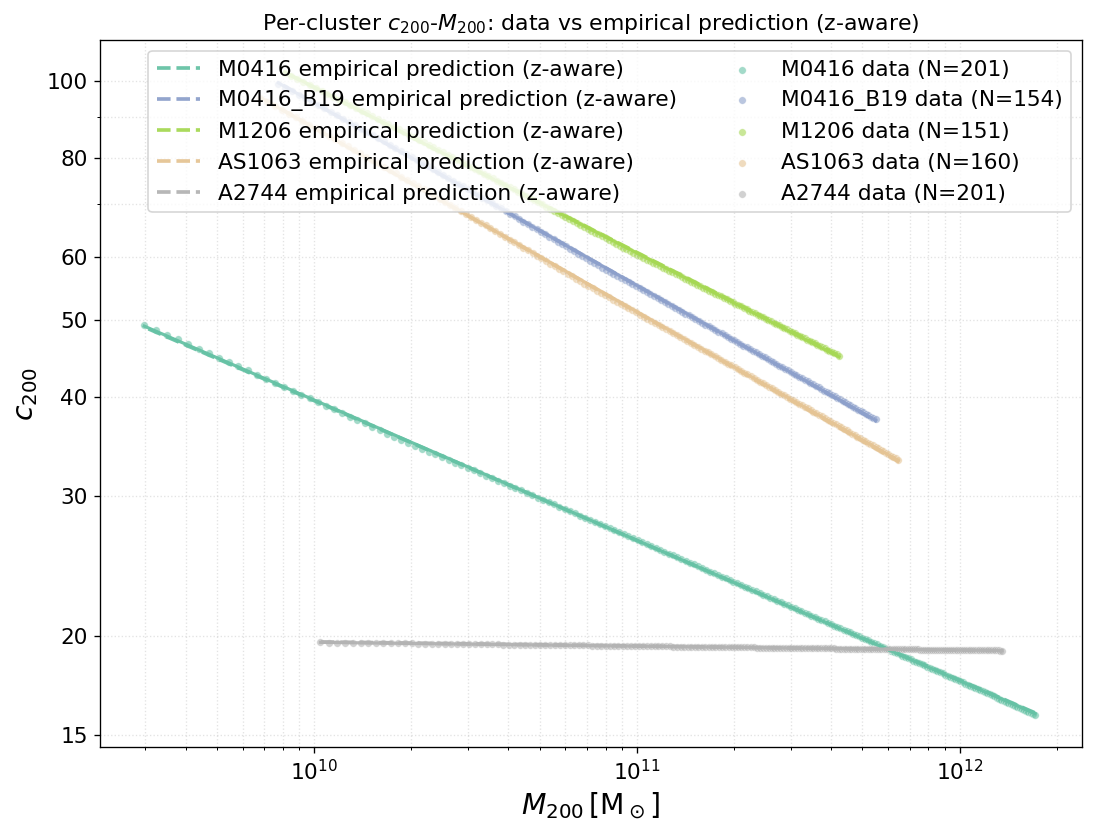

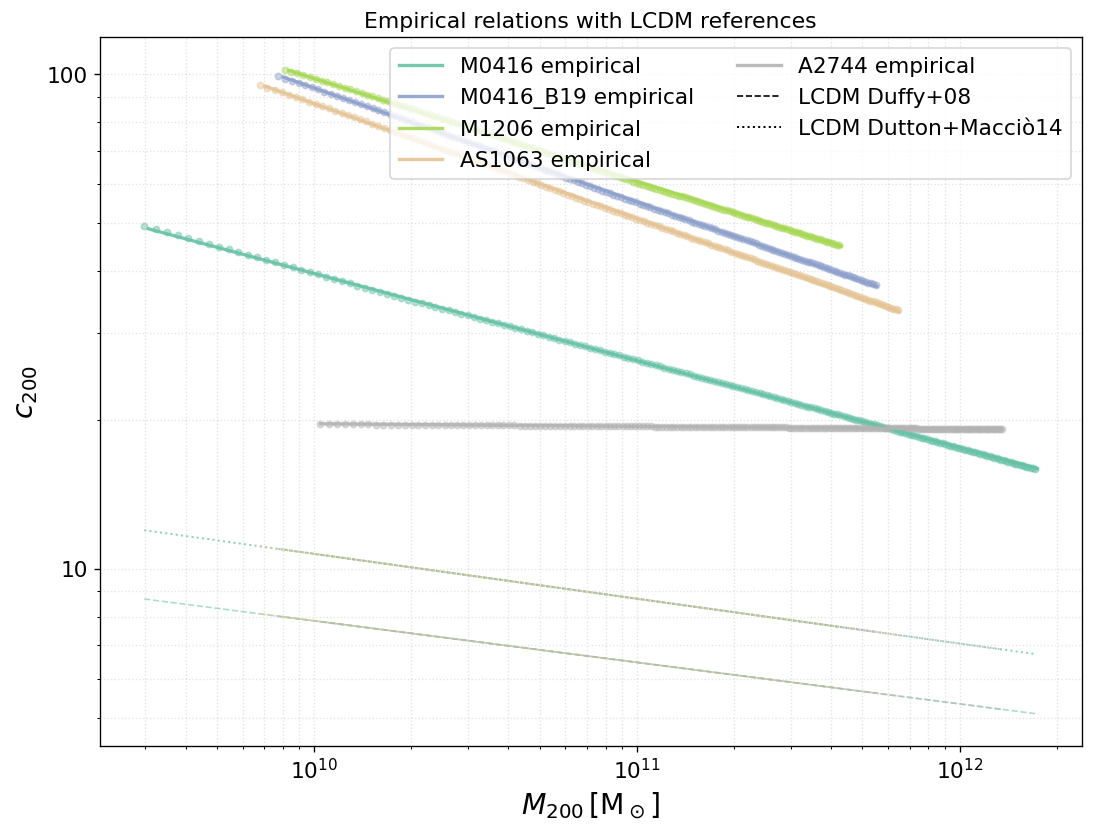

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from pathlib import Path
from pathlib import Path
from matplotlib.ticker import FuncFormatter, NullFormatter

# Figure 1: data vs empirical prediction only (no LCDM overlays)
fig, ax = plt.subplots(figsize=(9.0, 6.8), constrained_layout=True)
cluster_order = [k for k in bergamini_files.keys() if k in set(cm_bmo['cluster'])]
colors = plt.cm.Set2(np.linspace(0, 1, max(1, len(cluster_order))))
rows_fit = []
rows_pred = []

for color, cluster in zip(colors, cluster_order):
    sub = cm_bmo.loc[cm_bmo['cluster'] == cluster].copy()
    if len(sub) < 5:
        continue

    # measured points
    ax.scatter(
        sub['M200_Msun'], sub['c200'],
        s=20, alpha=0.60, color=color,
        edgecolors='white', linewidths=0.30,
        label=f'{cluster} data (N={len(sub)})'
    )

    # measured c-M trend (solid)
    xm = np.log10(sub['M200_Msun'].values / 1e12)
    ym = np.log10(sub['c200'].values)
    b_meas, a_meas = np.polyfit(xm, ym, 1)
    xx = np.linspace(xm.min(), xm.max(), 180)
    yy = a_meas + b_meas * xx
    ax.plot(10 ** (xx + 12), 10 ** yy, '-', color=color, lw=1.9, alpha=0.95)

    # z-aware predicted line
    rref = float(np.nanmedian(sub['rcut_ref_cluster_kpc'].values))
    beta = float(np.nanmedian(sub['beta_cluster'].values))
    z_model = float(np.nanmedian(sub['z_model_cluster'].values)) if np.isfinite(sub['z_model_cluster'].values).any() else None

    sig_grid = np.linspace(sub['sigma0_km_s'].min(), sub['sigma0_km_s'].max(), 220)
    m_pred = predict_m200_from_sigma_params(sig_grid, beta=beta, rcut_ref_kpc=rref, z_lens=z_model)
    c_pred = predict_c200_from_sigma_params(sig_grid, beta=beta, rcut_ref_kpc=rref, z_lens=z_model)
    ord_idx = np.argsort(m_pred)
    ax.plot(
        m_pred[ord_idx], c_pred[ord_idx], '--',
        color=color, lw=2.2, alpha=0.95,
        label=f'{cluster} empirical prediction (z-aware)'
    )

    # diagnostics on cluster points
    m_pred_pts = predict_m200_from_sigma_params(sub['sigma0_km_s'].values, beta=beta, rcut_ref_kpc=rref, z_lens=z_model)
    c_pred_pts = predict_c200_from_sigma_params(sub['sigma0_km_s'].values, beta=beta, rcut_ref_kpc=rref, z_lens=z_model)
    rms_logM = np.sqrt(np.mean((np.log10(sub['M200_Msun'].values) - np.log10(m_pred_pts)) ** 2))
    rms_logc = np.sqrt(np.mean((np.log10(sub['c200'].values) - np.log10(c_pred_pts)) ** 2))

    b_pred, a_pred = np.polyfit(np.log10(m_pred / 1e12), np.log10(c_pred), 1)

    rows_fit.append({
        'cluster': cluster,
        'measured_slope_dlogc_dlogM': b_meas,
        'measured_intercept_logc_at_1e12': a_meas,
        'N_used': len(sub),
    })
    rows_pred.append({
        'cluster': cluster,
        'predicted_slope_dlogc_dlogM': b_pred,
        'predicted_intercept_logc_at_1e12': a_pred,
        'z_model_used': z_model,
        'rms_logM_dex': rms_logM,
        'rms_logc_dex': rms_logc,
        'rcut_ref_kpc': rref,
        'beta': beta,
        'N': len(sub),
    })

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$M_{200}\,[\mathrm{M_\odot}]$', fontsize=17)
ax.set_ylabel(r'$c_{200}$', fontsize=17)
ax.set_title(r'Per-cluster $c_{200}$-$M_{200}$: data vs empirical prediction (z-aware)')
ax.grid(True, which='both', ls=':', alpha=0.35)

ytick_candidates = np.array([2, 3, 4, 5, 6, 8, 10, 15, 20, 30, 40, 50, 60, 80, 100, 150, 200, 300], dtype=float)
ymin, ymax = ax.get_ylim()
yt = ytick_candidates[(ytick_candidates >= ymin * 0.95) & (ytick_candidates <= ymax * 1.05)]
if len(yt) > 0:
    ax.set_yticks(yt)
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:g}' if y > 0 else ''))
ax.yaxis.set_minor_formatter(NullFormatter())

ax.tick_params(labelsize=13)
ax.legend(loc='best', fontsize=13, ncol=2)
out_fig = base_fitp / 'tutorial_c200_m200_bergamini_bmo_comparison.png'
fig.savefig(out_fig, dpi=180)
print(f'Saved: {out_fig}')

# Optional figure with LCDM references
def c200_duffy08(m200_msun, z, h=0.7):
    m = np.asarray(m200_msun, dtype=float)
    return 5.71 * ((m * h) / (2.0e12)) ** (-0.084) * (1.0 + z) ** (-0.47)


def c200_maccio14(m200_msun, z, h=0.7):
    z = max(float(z), 0.0)
    a = 0.520 + (0.905 - 0.520) * np.exp(-0.617 * (z ** 1.21))
    b = -0.101 + 0.026 * z
    xh = np.log10((np.asarray(m200_msun, dtype=float) * h) / 1.0e12)
    return 10.0 ** (a + b * xh)

fig2, ax2 = plt.subplots(figsize=(9.0, 6.8), constrained_layout=True)
for color, cluster in zip(colors, cluster_order):
    sub = cm_bmo.loc[cm_bmo['cluster'] == cluster].copy()
    if len(sub) < 5:
        continue
    ax2.scatter(sub['M200_Msun'], sub['c200'], s=14, alpha=0.45, color=color)

    rref = float(np.nanmedian(sub['rcut_ref_cluster_kpc'].values))
    beta = float(np.nanmedian(sub['beta_cluster'].values))
    z_model = float(np.nanmedian(sub['z_model_cluster'].values)) if np.isfinite(sub['z_model_cluster'].values).any() else None
    sig_grid = np.linspace(sub['sigma0_km_s'].min(), sub['sigma0_km_s'].max(), 220)
    m_pred = predict_m200_from_sigma_params(sig_grid, beta=beta, rcut_ref_kpc=rref, z_lens=z_model)
    c_pred = predict_c200_from_sigma_params(sig_grid, beta=beta, rcut_ref_kpc=rref, z_lens=z_model)
    ord_idx = np.argsort(m_pred)
    ax2.plot(m_pred[ord_idx], c_pred[ord_idx], '-', color=color, lw=2.0, alpha=0.9, label=f'{cluster} empirical')

    zc = z_model if z_model is not None else np.nan
    if np.isfinite(zc):
        m_grid = np.logspace(np.log10(sub['M200_Msun'].min()), np.log10(sub['M200_Msun'].max()), 120)
        ax2.plot(m_grid, c200_duffy08(m_grid, zc, h=0.7), ls='--', lw=1.0, color=color, alpha=0.55)
        ax2.plot(m_grid, c200_maccio14(m_grid, zc, h=0.7), ls=':', lw=1.2, color=color, alpha=0.75)

ax2.plot([], [], ls='--', color='black', lw=1.0, label='LCDM Duffy+08')
ax2.plot([], [], ls=':', color='black', lw=1.2, label='LCDM Dutton+Macciò14')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'$M_{200}\,[\mathrm{M_\odot}]$', fontsize=17)
ax2.set_ylabel(r'$c_{200}$', fontsize=17)
ax2.set_title(r'Empirical relations with LCDM references')
ax2.grid(True, which='both', ls=':', alpha=0.35)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:g}' if y > 0 else ''))
ax2.yaxis.set_minor_formatter(NullFormatter())
ax2.tick_params(labelsize=13)
ax2.legend(loc='best', fontsize=13, ncol=2)
out_fig_lcdm = base_fitp / 'tutorial_c200_m200_bergamini_bmo_with_lcdm.png'
fig2.savefig(out_fig_lcdm, dpi=180)
print(f'Saved: {out_fig_lcdm}')

if len(rows_fit):
    fit_df = pd.DataFrame(rows_fit)
    print('Measured c-M fits by cluster:')
    display(fit_df)
if len(rows_pred):
    pred_df = pd.DataFrame(rows_pred)
    print('Predicted c-M diagnostics (z-aware two-stage empirical model):')
    display(pred_df)
    merged = fit_df[['cluster', 'measured_slope_dlogc_dlogM', 'measured_intercept_logc_at_1e12']].merge(
        pred_df[['cluster', 'predicted_slope_dlogc_dlogM', 'predicted_intercept_logc_at_1e12']],
        on='cluster', how='left'
    )
    merged['delta_slope'] = merged['predicted_slope_dlogc_dlogM'] - merged['measured_slope_dlogc_dlogM']
    merged['delta_intercept'] = merged['predicted_intercept_logc_at_1e12'] - merged['measured_intercept_logc_at_1e12']
    print('Measured vs predicted c-M relation deltas:')
    display(merged)



Saved: /Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs/tutorial_sigma0_vs_rcut_bergamini_bmo_clusters.png


,cluster,slope_beta,rcut_ref_at_220_kms_kpc,N_used
0,M0416,2.000000,38.403512,201
1,M0416_B19,2.478405,10.498584,154
2,M1206,2.281150,8.204011,151
3,AS1063,2.493333,12.436935,160
4,A2744,1.021909,33.404330,201


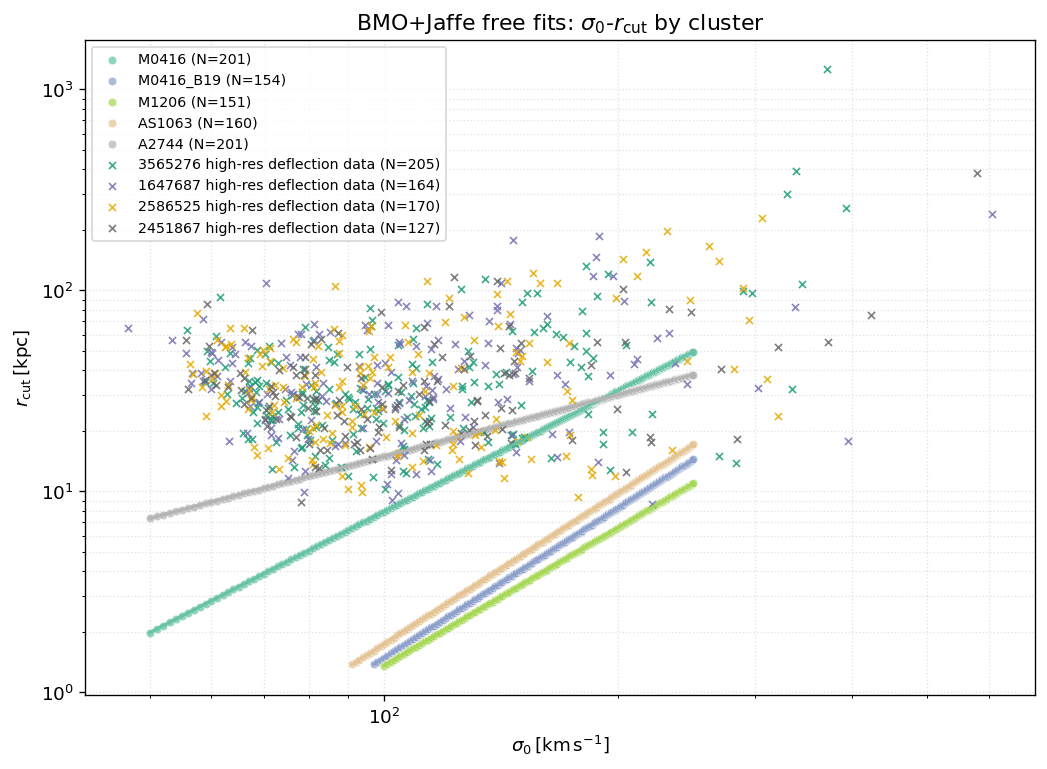

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

fig, ax = plt.subplots(figsize=(8.6, 6.3), constrained_layout=True)

extra_csv = Path('/Users/maxmen3/Downloads/deflection_outputs/piemd_datapoin.csv')
extra_df = None
if extra_csv.exists():
    extra_df = pd.read_csv(extra_csv)
    extra_df['sigma_0'] = pd.to_numeric(extra_df.get('sigma_0'), errors='coerce')
    extra_df['r_trunc_kpc'] = pd.to_numeric(extra_df.get('r_trunc_kpc'), errors='coerce')
    extra_df['sample_label'] = extra_df.get('sample_label', 'extra')
    ok_extra = np.isfinite(extra_df['sigma_0']) & np.isfinite(extra_df['r_trunc_kpc'])
    ok_extra &= (extra_df['sigma_0'] > 0) & (extra_df['r_trunc_kpc'] > 0)
    extra_df = extra_df.loc[ok_extra].copy()


cluster_order = [k for k in bergamini_files.keys() if k in set(cm_bmo['cluster'])]
colors = plt.cm.Set2(np.linspace(0, 1, max(1, len(cluster_order))))
rows = []

for color, cluster in zip(colors, cluster_order):
    sub = cm_bmo.loc[cm_bmo['cluster'] == cluster].copy()
    ok = np.isfinite(sub['sigma0_km_s']) & np.isfinite(sub['r_cut_kpc']) & (sub['sigma0_km_s'] > 0) & (sub['r_cut_kpc'] > 0)
    sub = sub.loc[ok]
    if len(sub) == 0:
        continue

    ax.scatter(sub['sigma0_km_s'], sub['r_cut_kpc'], s=26, alpha=0.72,
               color=color, edgecolors='white', linewidths=0.4,
               label=f'{cluster} (N={len(sub)})')

    if len(sub) >= 5:
        x = np.log10(sub['sigma0_km_s'].values / 220.0)
        y = np.log10(sub['r_cut_kpc'].values)
        slope, intercept = np.polyfit(x, y, 1)

        xg = np.linspace(sub['sigma0_km_s'].min(), sub['sigma0_km_s'].max(), 200)
        yg = 10 ** (intercept + slope * np.log10(xg / 220.0))
        ax.plot(xg, yg, '-', color=color, lw=2.0, alpha=0.95)

        rows.append({
            'cluster': cluster,
            'slope_beta': slope,
            'rcut_ref_at_220_kms_kpc': 10**intercept,
            'N_used': len(sub),
        })

if extra_df is not None and len(extra_df) > 0:
    extra_labels = list(dict.fromkeys(extra_df['sample_label'].astype(str).tolist()))
    extra_colors = plt.cm.Dark2(np.linspace(0, 1, max(1, len(extra_labels))))
    for color, label in zip(extra_colors, extra_labels):
        sub = extra_df.loc[extra_df['sample_label'].astype(str) == label]
        ax.scatter(sub['sigma_0'], sub['r_trunc_kpc'], s=18, marker='x', alpha=0.85,
                   color=color, linewidths=1.0, label=f'{label} deflection data (N={len(sub)})')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\sigma_0\,[\mathrm{km\,s^{-1}}]$')
ax.set_ylabel(r'$r_{\mathrm{cut}}\,[\mathrm{kpc}]$')
ax.set_title(r'BMO+Jaffe free fits: $\sigma_0$-$r_{\mathrm{cut}}$ by cluster')
ax.grid(True, which='both', ls=':', alpha=0.35)
ax.legend(loc='best', fontsize=8.5)

out_fig_sr = base_fitp / 'tutorial_sigma0_vs_rcut_bergamini_bmo_clusters.png'
fig.savefig(out_fig_sr, dpi=180)
print(f'Saved: {out_fig_sr}')

if len(rows) > 0:
    display(pd.DataFrame(rows))


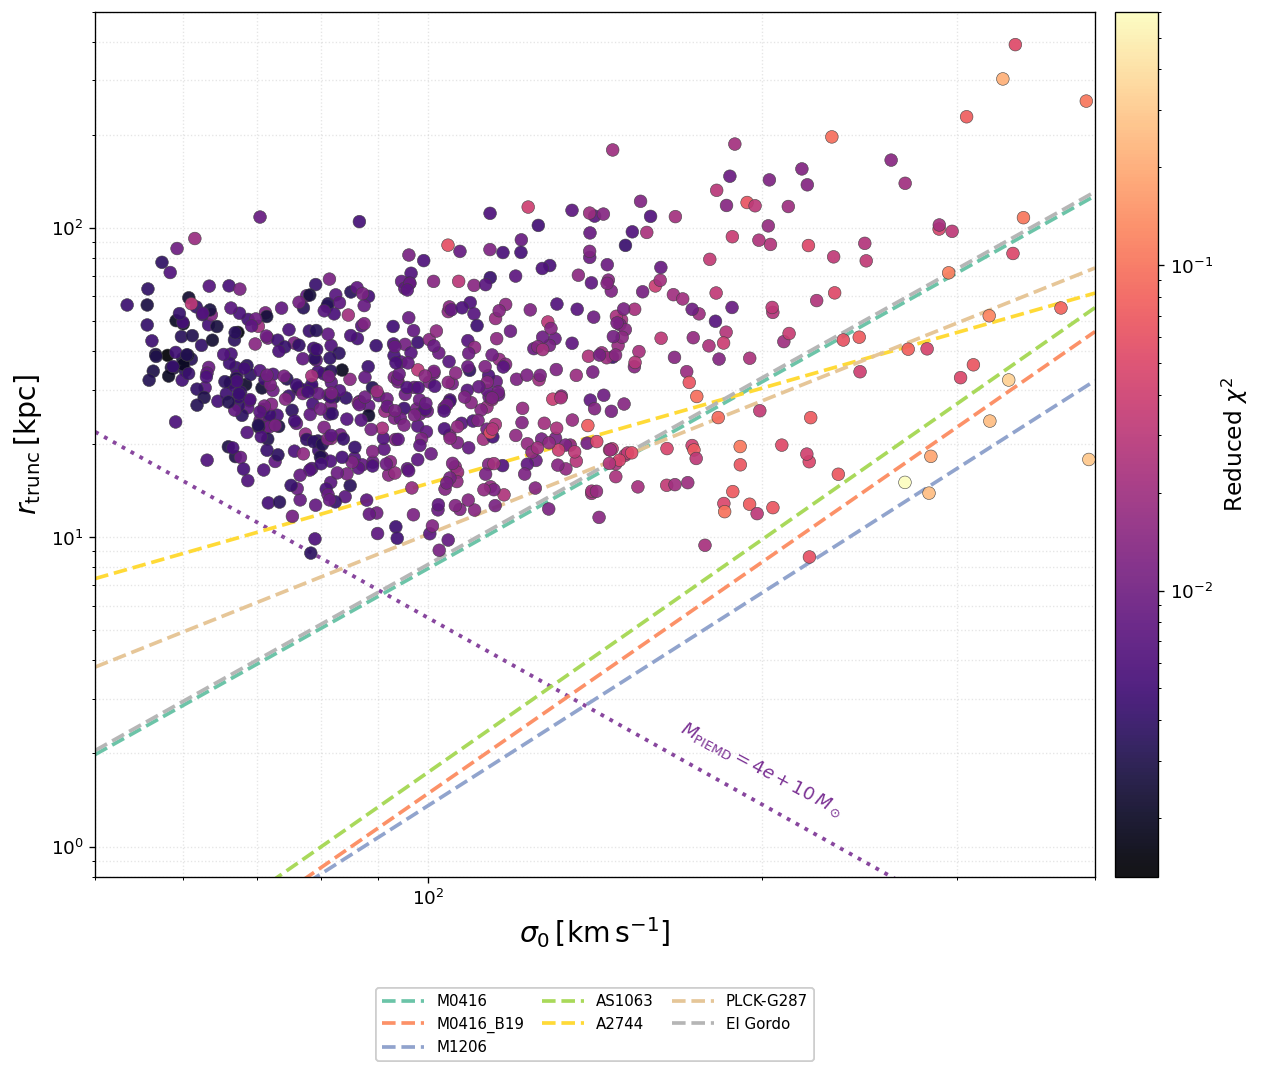

Saved: /Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs/tutorial_sigma0_vs_rcut_all_clusters_with_deflection_overlay.png


In [113]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib.ticker import NullFormatter
from pathlib import Path

if 'cm_bmo' not in globals() or len(cm_bmo) == 0:
    raise RuntimeError('Run the BMO+Jaffe calibration cell first so cm_bmo is available.')

extra_csv = Path('/Users/maxmen3/Downloads/deflection_outputs/piemd_datapoin.csv')
extra_df = pd.read_csv(extra_csv) if extra_csv.exists() else pd.DataFrame()
if len(extra_df) > 0:
    extra_df['sigma_0'] = pd.to_numeric(extra_df.get('sigma_0'), errors='coerce')
    extra_df['r_trunc_kpc'] = pd.to_numeric(extra_df.get('r_trunc_kpc'), errors='coerce')
    extra_df['chi2_reduced'] = pd.to_numeric(extra_df.get('chi2_reduced'), errors='coerce')
    extra_df['sample_label'] = extra_df.get('sample_label', 'extra')
    ok_extra = np.isfinite(extra_df['sigma_0']) & np.isfinite(extra_df['r_trunc_kpc']) & np.isfinite(extra_df['chi2_reduced'])
    ok_extra &= (extra_df['sigma_0'] > 0) & (extra_df['r_trunc_kpc'] > 0) & (extra_df['chi2_reduced'] > 0)
    extra_df = extra_df.loc[ok_extra].copy()

def piemd_mass_line(mass_msun, sigma_grid, g_kpc=None):
    g = float(g_kpc if g_kpc is not None else globals().get('G_KPC', 4.302e-6))
    sigma_grid = np.asarray(sigma_grid, dtype=float)
    return mass_msun * g / (np.pi * sigma_grid**2)

def line_rotation_from_data(ax, x1, y1, x2, y2):
    p1 = ax.transData.transform((x1, y1))
    p2 = ax.transData.transform((x2, y2))
    return float(np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0])))

def load_cluster_frame(csv_path):
    df = pd.read_csv(csv_path)
    fit_ok = df['fit_success'].astype(str).str.lower().isin(['true', '1', 'yes']) if 'fit_success' in df.columns else np.ones(len(df), dtype=bool)
    for col in ['sigma0_km_s', 'r_cut_kpc', 'M200_Msun', 'c200', 'z_lens']:
        if col in df.columns:
            df[col] = pd.to_numeric(df.get(col), errors='coerce')
    ok = fit_ok & np.isfinite(df['sigma0_km_s']) & np.isfinite(df['r_cut_kpc'])
    ok &= (df['sigma0_km_s'] > 0) & (df['r_cut_kpc'] > 0)
    if 'M200_Msun' in df.columns:
        ok &= np.isfinite(df['M200_Msun']) & (df['M200_Msun'] > 0)
    if 'c200' in df.columns:
        ok &= np.isfinite(df['c200']) & (df['c200'] > 0)
    return df.loc[ok].copy()

cluster_sources = []
for cluster in bergamini_files.keys():
    cluster_sources.append((cluster, base_fitp / bergamini_files[cluster]))
for cluster, cfg in [('PLCK-G287', {'csv': 'PLCK-G287_jaffe_bmo.csv'}), ('El Gordo', {'csv': 'elgordo_jaffe_bmo.csv'})]:
    fcsv = base_fitp / cfg['csv']
    if fcsv.exists():
        cluster_sources.append((cluster, fcsv))

cluster_frames = []
for cluster, fcsv in cluster_sources:
    try:
        sub = load_cluster_frame(fcsv)
    except Exception:
        continue
    if len(sub) == 0:
        continue
    sub = sub.copy()
    sub['cluster'] = cluster
    cluster_frames.append(sub)

if len(cluster_frames) == 0:
    raise RuntimeError('No cluster data available for the combined figure.')

all_clusters = pd.concat(cluster_frames, ignore_index=True)
cluster_order = list(dict.fromkeys(all_clusters['cluster'].tolist()))
colors = plt.cm.Set2(np.linspace(0, 1, max(1, len(cluster_order))))
color_map = {cluster: color for cluster, color in zip(cluster_order, colors)}

fig, ax = plt.subplots(figsize=(10.4, 7.9), constrained_layout=True)

# Soft background points so the fitted cluster curves remain easy to read.
#ax.scatter(all_clusters['sigma0_km_s'], all_clusters['r_cut_kpc'], s=14, alpha=0.11, color='0.15', linewidths=0, zorder=1)

x_all = all_clusters['sigma0_km_s'].to_numpy(dtype=float)
sigma_grid = np.logspace(np.log10(50.0), np.log10(400.0), 300)

legend_handles = []
legend_labels = []

for cluster in cluster_order:
    sub = all_clusters.loc[all_clusters['cluster'] == cluster].copy()
    color = color_map[cluster]

    #ax.scatter(sub['sigma0_km_s'], sub['r_cut_kpc'], s=34, alpha=0.72, color=color, edgecolors='white', linewidths=0.35, #zorder=3)

    if len(sub) >= 5:
        x = np.log10(sub['sigma0_km_s'].values / 220.0)
        y = np.log10(sub['r_cut_kpc'].values)
        slope, intercept = np.polyfit(x, y, 1)
        yg = 10 ** (intercept + slope * np.log10(sigma_grid / 220.0))
        line, = ax.plot(sigma_grid, yg, '--', color=color, lw=2.2, alpha=0.96, zorder=2)
    else:
        line, = ax.plot([], [], '--', color=color, lw=2.2, alpha=0.96)

    legend_handles.append(line)
    legend_labels.append(cluster)

if len(extra_df) > 0:
    cmin = float(np.nanmin(extra_df['chi2_reduced'].values))
    cmax = float(np.nanmax(extra_df['chi2_reduced'].values))
    norm = LogNorm(vmin=max(cmin, 1e-4), vmax=max(cmax, max(cmin * 1.01, 1e-3)))
    chi2lim=1.0
    sc = ax.scatter(
        extra_df['sigma_0'][extra_df['chi2_reduced']<chi2lim], extra_df['r_trunc_kpc'][extra_df['chi2_reduced']<chi2lim],
        c=extra_df['chi2_reduced'][extra_df['chi2_reduced']<chi2lim], cmap='magma', norm=norm,
        s=58, alpha=0.92, edgecolors='0.25', linewidths=0.35, zorder=4
    )
    cbar = fig.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_label(r'Reduced $\chi^2$', fontsize=14)

    xw = np.log10(extra_df['sigma_0'].to_numpy(dtype=float) / 220.0)
    yw = np.log10(extra_df['r_trunc_kpc'].to_numpy(dtype=float))
    ww = 1.0 / np.sqrt(extra_df['chi2_reduced'].to_numpy(dtype=float))
    beta_w, log_rref_w = np.polyfit(xw, yw, 1, w=ww)
    rref_w = float(10 ** log_rref_w)
    sigma_fit = np.logspace(np.log10(50.0), np.log10(400.0), 300)
    r_fit = rref_w * (sigma_fit / 220.0) ** beta_w
    fit_line, = ax.plot(sigma_fit, r_fit, color='black', lw=2.8, zorder=5,
                        label=rf'weighted fit ($\beta={beta_w:.3f}$)')
    legend_handles.append(fit_line)
    legend_labels.append(rf'weighted fit ($\beta={beta_w:.3f}$)')

mass_lines = [4e10]#, 2.99e11, 1.24e12, 6.9e12, 1.27e14]
mass_colors = ['#7b3294']#, '#5e81b5', '#4db7b2', '#70cf57', '#f6d743']
fig.canvas.draw()
mass_x_positions = [200]#[52.0, 58.0, 66.0, 78.0, 96.0]
for mass_msun, line_color, x_text in zip(mass_lines, mass_colors, mass_x_positions):
    y_line = piemd_mass_line(mass_msun, sigma_grid)
    ax.plot(sigma_grid, y_line, ':', color=line_color, lw=2.3, alpha=0.9, zorder=1)
    x1 = x_text
    x2 = min(x_text * 1.35, 395.0)
    y1 = float(piemd_mass_line(mass_msun, np.array([x1]))[0])+0.4
    y2 = float(piemd_mass_line(mass_msun, np.array([x2]))[0])
    rot = -28#line_rotation_from_data(ax, x1, y1, x2, y2)
    ax.text(
        x1, y1,
        rf'$M_{{\mathrm{{PIEMD}}}} = {mass_msun:.2g}\,M_\odot$',
        color=line_color, fontsize=11, rotation=rot, rotation_mode='anchor',
        ha='center', va='center', weight='bold'
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(50.0, 400.0)
ax.set_ylim(8e-1, 500)
ax.set_xlabel(r'$\sigma_0\,[\mathrm{km\,s^{-1}}]$', fontsize=17)
ax.set_ylabel(r'$r_{\mathrm{trunc}}\,[\mathrm{kpc}]$', fontsize=17)
#ax.set_title(r'$r_{\mathrm{trunc}}$ vs. $\sigma_0$ for BMO+Jaffe free fits', fontsize=18)
ax.grid(True, which='both', ls=':', alpha=0.32)
ax.yaxis.set_minor_formatter(NullFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())

cluster_leg = ax.legend(
    handles=legend_handles, labels=legend_labels,
    loc='upper center', bbox_to_anchor=(0.50, -0.12),
    ncol=3, fontsize=9, frameon=True, framealpha=0.92, columnspacing=1.2, handlelength=2.8
)
ax.add_artist(cluster_leg)
plt.show()

out_fig_all = base_fitp / 'tutorial_sigma0_vs_rcut_all_clusters_with_deflection_overlay.png'
fig.savefig(out_fig_all, dpi=180, bbox_inches='tight')
print(f'Saved: {out_fig_all}')


Saved: /Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs/tutorial_bmo_free_sigma0_rtrunc_and_cM_by_cluster.png


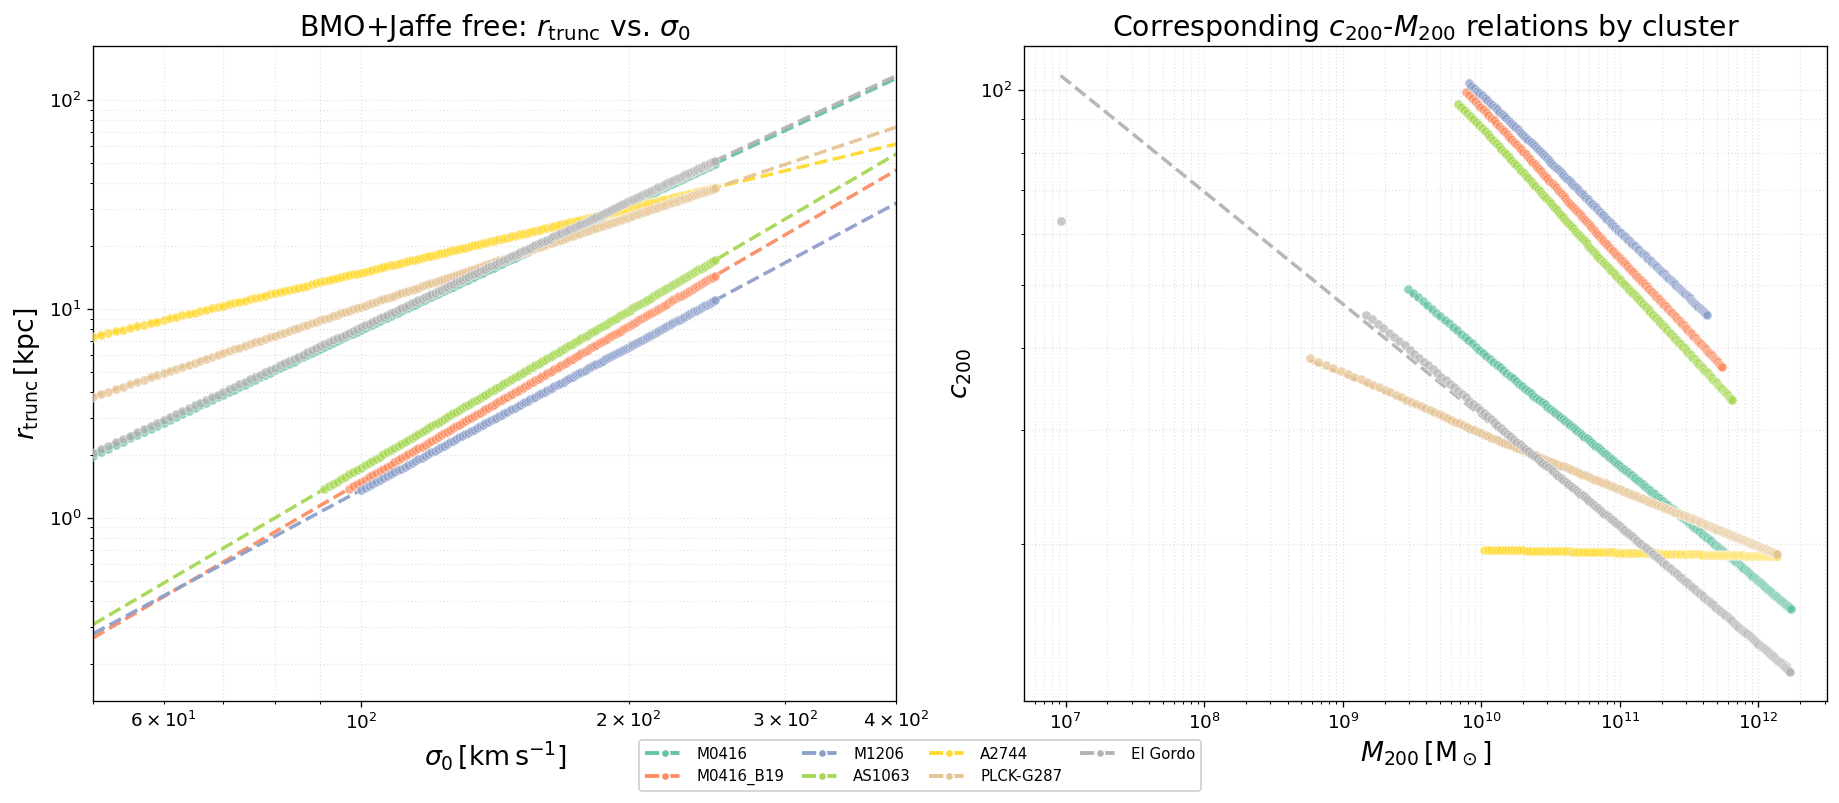

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path

if 'base_fitp' not in globals():
    base_fitp = Path('/Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs')

cluster_specs = [
    ('M0416', 'M0416_jaffe_bmo.csv'),
    ('M0416_B19', 'M0416_B19_jaffe_bmo.csv'),
    ('M1206', 'M1206_jaffe_bmo.csv'),
    ('AS1063', 'AS1063_jaffe_bmo.csv'),
    ('A2744', 'A2744_jaffe_bmo.csv'),
    ('PLCK-G287', 'PLCK-G287_jaffe_bmo.csv'),
    ('El Gordo', 'elgordo_jaffe_bmo.csv'),
]

def load_cluster_frame(csv_path):
    df = pd.read_csv(csv_path)
    fit_ok = df['fit_success'].astype(str).str.lower().isin(['true', '1', 'yes']) if 'fit_success' in df.columns else np.ones(len(df), dtype=bool)
    for col in ['sigma0_km_s', 'r_cut_kpc', 'M200_Msun', 'c200', 'z_lens']:
        if col in df.columns:
            df[col] = pd.to_numeric(df.get(col), errors='coerce')
    ok = fit_ok & np.isfinite(df['sigma0_km_s']) & np.isfinite(df['r_cut_kpc'])
    ok &= (df['sigma0_km_s'] > 0) & (df['r_cut_kpc'] > 0)
    if 'M200_Msun' in df.columns:
        ok &= np.isfinite(df['M200_Msun']) & (df['M200_Msun'] > 0)
    if 'c200' in df.columns:
        ok &= np.isfinite(df['c200']) & (df['c200'] > 0)
    return df.loc[ok].copy()

def fit_powerlaw_logxlogy(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    ok = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if ok.sum() < 3:
        return np.nan, np.nan
    slope, intercept = np.polyfit(np.log10(x[ok]), np.log10(y[ok]), 1)
    return float(slope), float(intercept)

frames = []
legend_clusters = []
for cluster, fname in cluster_specs:
    fcsv = base_fitp / fname
    if not fcsv.exists():
        continue
    sub = load_cluster_frame(fcsv)
    if len(sub) == 0:
        continue
    sub = sub.copy()
    sub['cluster'] = cluster
    frames.append(sub)
    legend_clusters.append(cluster)

if len(frames) == 0:
    raise RuntimeError('No BMO+Jaffe cluster data were available for the summary figure.')

data = pd.concat(frames, ignore_index=True)
cluster_order = legend_clusters
colors = plt.cm.Set2(np.linspace(0, 1, max(1, len(cluster_order))))
color_map = {cluster: color for cluster, color in zip(cluster_order, colors)}

fig, axs = plt.subplots(1, 2, figsize=(15.2, 6.4), constrained_layout=True)
ax_l, ax_r = axs

# Left panel: r_trunc vs sigma0
for cluster in cluster_order:
    sub = data.loc[data['cluster'] == cluster].copy()
    color = color_map[cluster]
    ax_l.scatter(sub['sigma0_km_s'], sub['r_cut_kpc'], s=30, alpha=0.72, color=color, edgecolors='white', linewidths=0.35, zorder=3)
    if len(sub) >= 5:
        slope, intercept = fit_powerlaw_logxlogy(sub['sigma0_km_s'].values / 220.0, sub['r_cut_kpc'].values)
        xg = np.logspace(np.log10(50.0), np.log10(400.0), 240)
        yg = 10 ** (intercept + slope * np.log10(xg / 220.0))
        ax_l.plot(xg, yg, '--', color=color, lw=2.1, alpha=0.95, zorder=2)

ax_l.set_xscale('log')
ax_l.set_yscale('log')
ax_l.set_xlim(50.0, 400.0)
ax_l.set_xlabel(r'$\sigma_0\,[\mathrm{km\,s^{-1}}]$', fontsize=16)
ax_l.set_ylabel(r'$r_{\mathrm{trunc}}\,[\mathrm{kpc}]$', fontsize=16)
ax_l.set_title(r'BMO+Jaffe free: $r_{\mathrm{trunc}}$ vs. $\sigma_0$', fontsize=17)
ax_l.grid(True, which='both', ls=':', alpha=0.32)

# Right panel: c-M relation
for cluster in cluster_order:
    sub = data.loc[data['cluster'] == cluster].copy()
    color = color_map[cluster]
    ok = np.isfinite(sub['M200_Msun']) & np.isfinite(sub['c200']) & (sub['M200_Msun'] > 0) & (sub['c200'] > 0)
    sub = sub.loc[ok]
    if len(sub) == 0:
        continue
    ax_r.scatter(sub['M200_Msun'], sub['c200'], s=30, alpha=0.72, color=color, edgecolors='white', linewidths=0.35, zorder=3)
    if len(sub) >= 5:
        slope, intercept = fit_powerlaw_logxlogy(sub['M200_Msun'].values, sub['c200'].values)
        xg = np.logspace(np.log10(sub['M200_Msun'].min()), np.log10(sub['M200_Msun'].max()), 240)
        yg = 10 ** (intercept + slope * np.log10(xg))
        ax_r.plot(xg, yg, '--', color=color, lw=2.1, alpha=0.95, zorder=2)

ax_r.set_xscale('log')
ax_r.set_yscale('log')
ax_r.set_xlabel(r'$M_{200}\,[\mathrm{M_\odot}]$', fontsize=16)
ax_r.set_ylabel(r'$c_{200}$', fontsize=16)
ax_r.set_title(r'Corresponding $c_{200}$-$M_{200}$ relations by cluster', fontsize=17)
ax_r.grid(True, which='both', ls=':', alpha=0.32)

legend_handles = [Line2D([0], [0], color=color_map[c], lw=2.3, ls='--', marker='o', markersize=5, markerfacecolor=color_map[c], markeredgecolor='white') for c in cluster_order]
fig.legend(legend_handles, cluster_order, loc='lower center', bbox_to_anchor=(0.5, -0.03), ncol=4, fontsize=9, frameon=True, framealpha=0.92, columnspacing=1.2, handlelength=2.6)

out_fig = base_fitp / 'tutorial_bmo_free_sigma0_rtrunc_and_cM_by_cluster.png'
fig.savefig(out_fig, dpi=180, bbox_inches='tight')
print(f'Saved: {out_fig}')


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path

csv_path = Path('/Users/maxmen3/Downloads/deflection_outputs/piemd_datapoin.csv')
if not csv_path.exists():
    raise FileNotFoundError(f'Missing CSV file: {csv_path}')

df = pd.read_csv(csv_path)
for col in ['sigma_0', 'r_trunc_kpc', 'chi2_reduced']:
    df[col] = pd.to_numeric(df.get(col), errors='coerce')

ok = np.isfinite(df['sigma_0']) & np.isfinite(df['r_trunc_kpc']) & np.isfinite(df['chi2_reduced'])
ok &= (df['sigma_0'] > 0) & (df['r_trunc_kpc'] > 0) & (df['chi2_reduced'] > 0)
sub = df.loc[ok].copy()
if len(sub) < 3:
    raise RuntimeError('Not enough valid points in the CSV for a weighted fit.')

x = np.log10(sub['sigma_0'].to_numpy() / 220.0)
y = np.log10(sub['r_trunc_kpc'].to_numpy())
chi2 = sub['chi2_reduced'].to_numpy()

# np.polyfit minimizes sum((w_i * residual_i)^2), so use sqrt(1/chi2)
# to make the effective least-squares weight scale like 1/chi2.
w = 1.0 / np.sqrt(chi2)
beta_w, log_rref_w = np.polyfit(x, y, 1, w=w)
rref_w = float(10 ** log_rref_w)

y_fit = log_rref_w + beta_w * x
rms_unweighted = float(np.sqrt(np.mean((y - y_fit) ** 2)))
rms_weighted = float(np.sqrt(np.average((y - y_fit) ** 2, weights=1.0 / chi2)))

print('Weighted log-linear fit for CSV datapoints')
print(f'  r_cut = {rref_w:.6g} * (sigma_0 / 220 km/s)^{beta_w:.6f}  [kpc]')
print(f'  beta = {beta_w:.6f}')
print(f'  r_cut_ref(220 km/s) = {rref_w:.6f} kpc')
print(f'  RMS residual (dex) = {rms_unweighted:.6f}')
print(f'  weighted RMS residual (dex) = {rms_weighted:.6f}')

fig, ax = plt.subplots(figsize=(8.8, 6.6), constrained_layout=True)
norm = LogNorm(vmin=max(float(sub['chi2_reduced'].min()), 1e-4), vmax=float(sub['chi2_reduced'].max()))
sc = ax.scatter(
    sub['sigma_0'], sub['r_trunc_kpc'],
    c=sub['chi2_reduced'], cmap='magma_r', norm=norm,
    s=24, alpha=0.88, edgecolors='0.25', linewidths=0.25
)

sigma_grid = np.logspace(np.log10(50.0), np.log10(400.0), 300)
r_line = rref_w * (sigma_grid / 220.0) ** beta_w
ax.plot(sigma_grid, r_line, color='black', lw=2.4, label=rf'weighted fit: $\beta={beta_w:.3f}$')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(50.0, 400.0)
ax.set_xlabel(r'$\sigma_0\,[\mathrm{km\,s^{-1}}]$', fontsize=16)
ax.set_ylabel(r'$r_{\mathrm{cut}}\,[\mathrm{kpc}]$', fontsize=16)
ax.set_title(r'Weighted linear fit in the $\log r_{\mathrm{cut}}$-$\log \sigma_0$ plane', fontsize=16)
ax.grid(True, which='both', ls=':', alpha=0.32)
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r'Reduced $\chi^2$', fontsize=14)
ax.legend(loc='best', fontsize=9, frameon=True, framealpha=0.92)

out_fig = Path('/Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs/tutorial_weighted_log_rcut_sigma_fit.png')
fig.savefig(out_fig, dpi=180, bbox_inches='tight')
print(f'Saved: {out_fig}')


### 9.3.1 External Validation on Previously Unused Clusters (PLCK-G287 and El Gordo)

To test whether the empirical parametrization is predictive (and not only descriptive of the calibration set),
we apply it to two additional clusters that were not used to calibrate the relation in Sect. 9.3:
`PLCK-G287` and `elgordo`.

For each cluster we:
1. read the BMO+Jaffe catalog,
2. fit the local $r_{\rm cut}(\sigma_0)$ relation to obtain $(r_{\rm cut,ref},\beta)$,
3. predict $M_{200}(\sigma_0\mid\beta,r_{\rm cut,ref})$ and $c_{200}(\sigma_0\mid\beta,r_{\rm cut,ref})$
   with the Sect. 9.3 parametrization,
4. compare measured and predicted $c_{200}$--$M_{200}$ relations.



Saved: /Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs/tutorial_c200_m200_external_validation_plck_elgordo.png
External validation diagnostics (no-z vs z-aware):


,cluster,N_valid,z_used,beta_fit,rcut_ref_kpc_fit,measured_slope_dlogc_dlogM,predicted_slope_dlogc_dlogM,delta_slope,rms_logM_noz_dex,rms_logc_noz_dex,rms_logM_zaware_dex,rms_logc_zaware_dex
0,PLCK-G287,225,0.3833,1.428571,31.581788,-0.088456,-0.087457,0.000999,0.004413,0.003499,0.004264,0.001908
1,elgordo,210,0.8703,2.000000,39.577592,-0.172502,-0.176140,-0.003637,0.035911,0.086578,0.033246,0.011221


Median RMS(logc): no-z, z-aware = 0.045038707685608144 0.006564523021652045


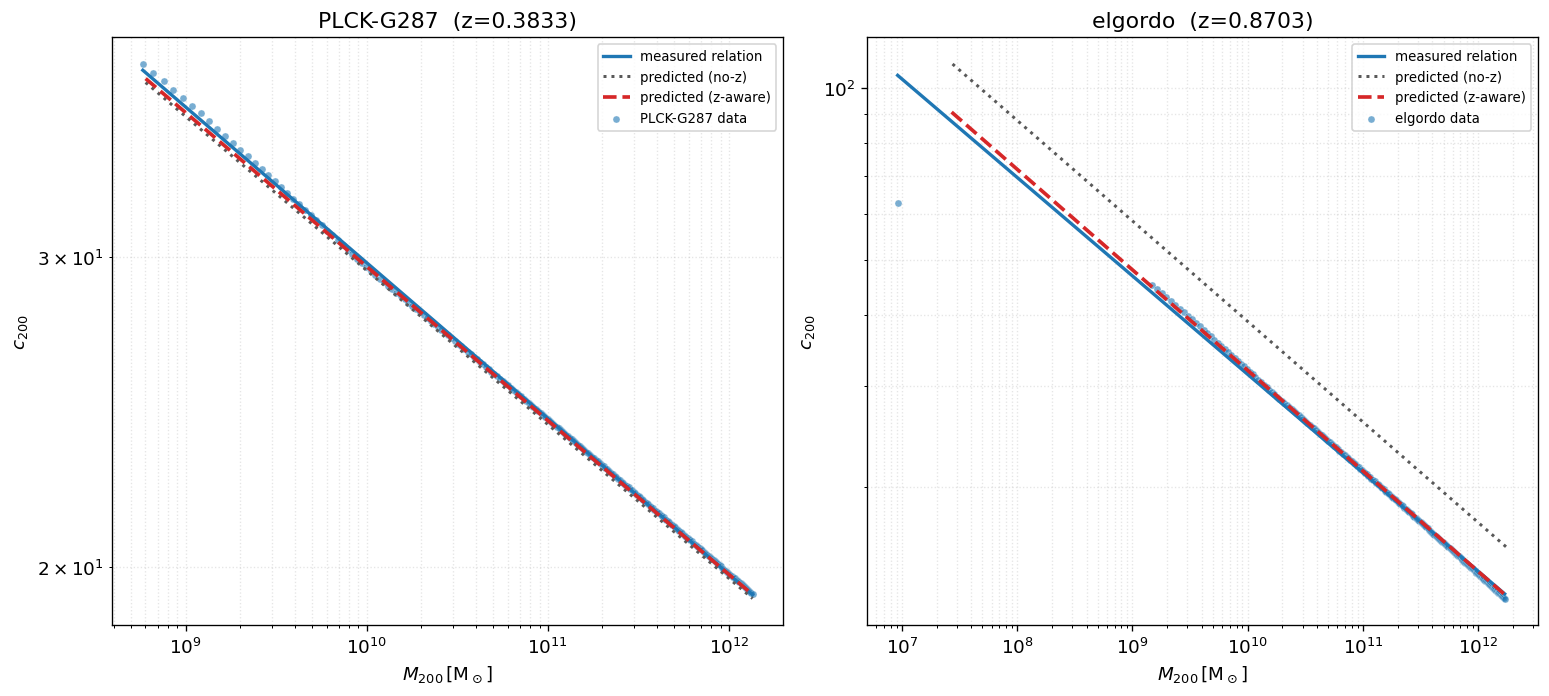

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if 'predict_m200_from_sigma_params' not in globals() or 'predict_c200_from_sigma_params' not in globals():
    raise RuntimeError('Run the Sect. 9.3 calibration cell first (cell 49).')

base_fitp = Path('/Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs')
extra_clusters = {
    'PLCK-G287': {
        'csv': 'PLCK-G287_jaffe_bmo.csv',
        'par': 'PLCK-G287.par',
    },
    'elgordo': {
        'csv': 'elgordo_jaffe_bmo.csv',
        'par': 'elgordo.par',
    },
}

SIG_REF = float(globals().get('SIGMA_REF', 220.0))


def _z_from_par_path(par_path):
    try:
        from pyLensLib.lenstool import getLensRedshift
        z = float(getLensRedshift(str(par_path)))
        if np.isfinite(z) and z > 0:
            return z
    except Exception:
        pass
    try:
        import re
        txt = Path(par_path).read_text()
        m = re.search(r'z_lens\s+([0-9.]+)', txt)
        if m:
            z = float(m.group(1))
            if np.isfinite(z) and z > 0:
                return z
    except Exception:
        pass
    return np.nan


fig, axs = plt.subplots(1, 2, figsize=(12.8, 5.7), constrained_layout=True)
rows = []

for ax, (cluster, cfg) in zip(axs, extra_clusters.items()):
    fcsv = base_fitp / cfg['csv']
    fpar = base_fitp / cfg['par']
    if not fcsv.exists():
        ax.text(0.5, 0.5, f'Missing file:\n{fcsv.name}', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    dfi = pd.read_csv(fcsv)
    fit_ok = dfi['fit_success'].astype(str).str.lower().isin(['true', '1', 'yes']) if 'fit_success' in dfi.columns else np.ones(len(dfi), dtype=bool)

    m200 = pd.to_numeric(dfi.get('M200_Msun'), errors='coerce')
    c200 = pd.to_numeric(dfi.get('c200'), errors='coerce')
    sig0 = pd.to_numeric(dfi.get('sigma0_km_s'), errors='coerce')
    rcut = pd.to_numeric(dfi.get('r_cut_kpc'), errors='coerce')
    zcsv = pd.to_numeric(dfi.get('z_lens'), errors='coerce')

    ok = fit_ok & np.isfinite(m200) & np.isfinite(c200) & np.isfinite(sig0) & np.isfinite(rcut)
    ok &= (m200 > 0) & (c200 > 0) & (sig0 > 0) & (rcut > 0)

    if ok.sum() < 8:
        ax.text(0.5, 0.5, f'Insufficient valid points\nfor {cluster}', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    m = m200[ok].values
    c = c200[ok].values
    s = sig0[ok].values
    r = rcut[ok].values
    z_data = float(np.nanmedian(zcsv[ok].values)) if np.isfinite(zcsv[ok].values).any() else np.nan

    if 'fit_rcut_sigma' in globals():
        rref, beta = fit_rcut_sigma(s, r, sigma_ref=SIG_REF)
    else:
        x_tmp = np.log10(np.asarray(s, dtype=float) / SIG_REF)
        y_tmp = np.log10(np.asarray(r, dtype=float))
        beta, log_rref = np.polyfit(x_tmp, y_tmp, 1)
        rref = float(10 ** log_rref)

    # no-z and z-aware predictions
    m_pred_noz = predict_m200_from_sigma_params(s, beta=beta, rcut_ref_kpc=rref, z_lens=None)
    c_pred_noz = predict_c200_from_sigma_params(s, beta=beta, rcut_ref_kpc=rref, z_lens=None)
    m_pred = predict_m200_from_sigma_params(s, beta=beta, rcut_ref_kpc=rref, z_lens=z_data)
    c_pred = predict_c200_from_sigma_params(s, beta=beta, rcut_ref_kpc=rref, z_lens=z_data)

    rms_logM_noz = float(np.sqrt(np.mean((np.log10(m) - np.log10(m_pred_noz)) ** 2)))
    rms_logc_noz = float(np.sqrt(np.mean((np.log10(c) - np.log10(c_pred_noz)) ** 2)))
    rms_logM = float(np.sqrt(np.mean((np.log10(m) - np.log10(m_pred)) ** 2)))
    rms_logc = float(np.sqrt(np.mean((np.log10(c) - np.log10(c_pred)) ** 2)))

    b_meas, a_meas = np.polyfit(np.log10(m / 1e12), np.log10(c), 1)
    b_pred, a_pred = np.polyfit(np.log10(m_pred / 1e12), np.log10(c_pred), 1)

    # Plot data and measured relation
    ax.scatter(m, c, s=18, alpha=0.60, color='tab:blue', edgecolors='white', linewidths=0.3, label=f'{cluster} data')
    xx = np.linspace(np.log10(m.min() / 1e12), np.log10(m.max() / 1e12), 180)
    yy_meas = a_meas + b_meas * xx
    ax.plot(10 ** (xx + 12), 10 ** yy_meas, '-', lw=2.0, color='tab:blue', label='measured relation')

    # predicted relations (no-z and z-aware)
    s_grid = np.linspace(s.min(), s.max(), 240)
    m_line_noz = predict_m200_from_sigma_params(s_grid, beta=beta, rcut_ref_kpc=rref, z_lens=None)
    c_line_noz = predict_c200_from_sigma_params(s_grid, beta=beta, rcut_ref_kpc=rref, z_lens=None)
    ord0 = np.argsort(m_line_noz)
    ax.plot(m_line_noz[ord0], c_line_noz[ord0], ':', lw=1.8, color='0.35', label='predicted (no-z)')

    m_line = predict_m200_from_sigma_params(s_grid, beta=beta, rcut_ref_kpc=rref, z_lens=z_data)
    c_line = predict_c200_from_sigma_params(s_grid, beta=beta, rcut_ref_kpc=rref, z_lens=z_data)
    ord1 = np.argsort(m_line)
    ax.plot(m_line[ord1], c_line[ord1], '--', lw=2.2, color='tab:red', label='predicted (z-aware)')

    zpar = _z_from_par_path(fpar) if fpar.exists() else np.nan
    ztitle = z_data if np.isfinite(z_data) else zpar
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$M_{200}\,[\mathrm{M_\odot}]$', fontsize=15)
    ax.set_ylabel(r'$c_{200}$', fontsize=15)
    ax.set_title(f'{cluster}  (z={ztitle:.4f})' if np.isfinite(ztitle) else cluster, fontsize=16)
    ax.grid(True, which='both', ls=':', alpha=0.32)
    ax.tick_params(labelsize=12)
    ax.legend(fontsize=12)

    rows.append({
        'cluster': cluster,
        'N_valid': int(len(s)),
        'z_used': ztitle,
        'beta_fit': float(beta),
        'rcut_ref_kpc_fit': float(rref),
        'measured_slope_dlogc_dlogM': float(b_meas),
        'predicted_slope_dlogc_dlogM': float(b_pred),
        'delta_slope': float(b_pred - b_meas),
        'rms_logM_noz_dex': rms_logM_noz,
        'rms_logc_noz_dex': rms_logc_noz,
        'rms_logM_zaware_dex': rms_logM,
        'rms_logc_zaware_dex': rms_logc,
    })

out_ext = base_fitp / 'tutorial_c200_m200_external_validation_plck_elgordo.png'
fig.savefig(out_ext, dpi=180)
print(f'Saved: {out_ext}')

if rows:
    df_val = pd.DataFrame(rows)
    print('External validation diagnostics (no-z vs z-aware):')
    display(df_val)
    print('Median RMS(logc): no-z, z-aware =',
          float(np.median(df_val['rms_logc_noz_dex'])),
          float(np.median(df_val['rms_logc_zaware_dex'])))
else:
    print('No external cluster diagnostics produced. Check input files.')



### 9.3.2 Impact of Redshift Dependence (El Gordo Diagnostic)

After introducing the redshift term in Sect. 9.3,
we explicitly compare El Gordo residuals for:

- the older no-redshift parametrization, and
- the new redshift-aware parametrization.

If redshift is the dominant source of mismatch, the residuals should collapse toward zero
when the $z$-dependent term is enabled.



El Gordo residuals: no-z vs z-aware
  z_obs = 0.8703, beta = 2.000000, rcut_ref = 39.577592 kpc
  no-z model:
    median dlogM = +0.0117, RMS dlogM = 0.0359
    median dlogc = +0.0853, RMS dlogc = 0.0866
  z-aware model:
    median dlogM = +0.0036, RMS dlogM = 0.0332
    median dlogc = +0.0011, RMS dlogc = 0.0112
Saved: /Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs/tutorial_elgordo_redshift_diagnostic.png


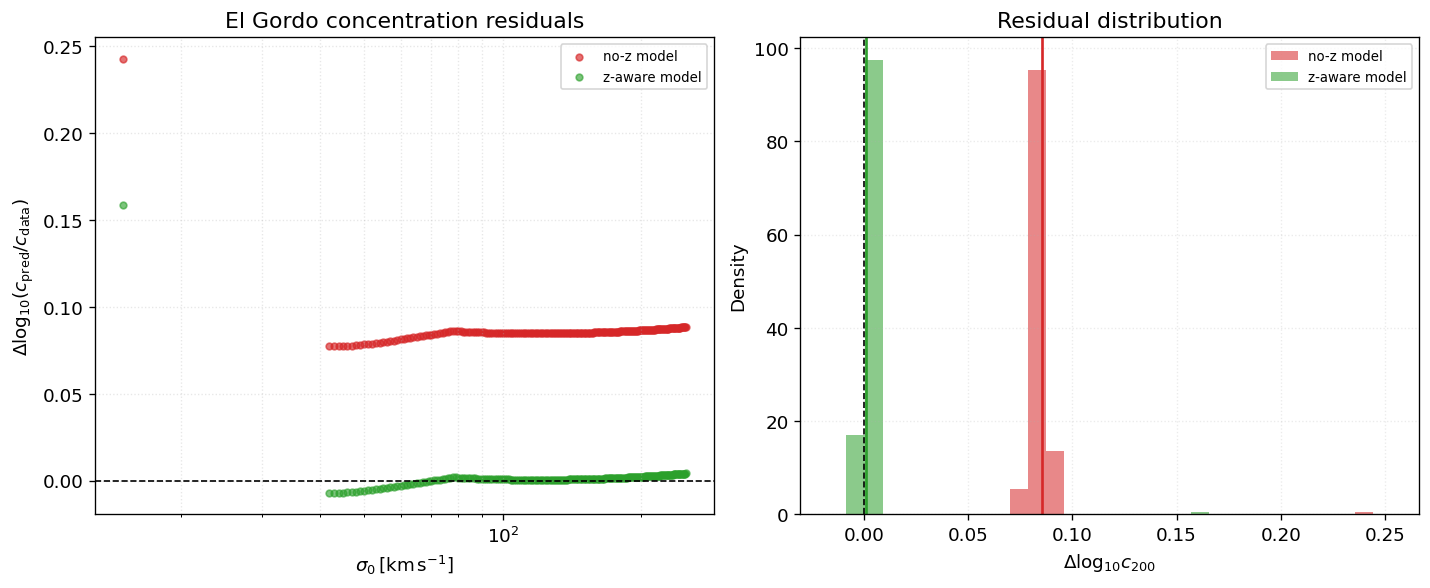

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

if 'predict_m200_from_sigma_params' not in globals() or 'predict_c200_from_sigma_params' not in globals():
    raise RuntimeError('Run Sect. 9.3 calibration cell first (cell 49).')

base_fitp = Path('/Users/maxmen3/projects/pyLensLib/apps/FitPIEMDs')
f_el = base_fitp / 'elgordo_jaffe_bmo.csv'
if not f_el.exists():
    raise FileNotFoundError(f'Missing file: {f_el}')

df = pd.read_csv(f_el)
fit_ok = df['fit_success'].astype(str).str.lower().isin(['true', '1', 'yes']) if 'fit_success' in df.columns else np.ones(len(df), dtype=bool)

for c in ['sigma0_km_s', 'r_cut_kpc', 'M200_Msun', 'c200', 'z_lens']:
    df[c] = pd.to_numeric(df.get(c), errors='coerce')

ok = fit_ok & np.isfinite(df['sigma0_km_s']) & np.isfinite(df['r_cut_kpc']) & np.isfinite(df['M200_Msun']) & np.isfinite(df['c200'])
ok &= (df['sigma0_km_s'] > 0) & (df['r_cut_kpc'] > 0) & (df['M200_Msun'] > 0) & (df['c200'] > 0)
sub = df.loc[ok].copy()
if len(sub) < 20:
    raise RuntimeError('Not enough valid El Gordo points for diagnostic.')

s = sub['sigma0_km_s'].to_numpy()
r = sub['r_cut_kpc'].to_numpy()
m_obs = sub['M200_Msun'].to_numpy()
c_obs = sub['c200'].to_numpy()
z_obs = float(np.nanmedian(sub['z_lens'].to_numpy())) if np.isfinite(sub['z_lens'].to_numpy()).any() else np.nan

# local scaling
xsr = np.log10(s / float(globals().get('SIGMA_REF', 220.0)))
beta, log_rref = np.polyfit(xsr, np.log10(r), 1)
rref = float(10 ** log_rref)

# predictions
m_pred_noz = predict_m200_from_sigma_params(s, beta=beta, rcut_ref_kpc=rref, z_lens=None)
c_pred_noz = predict_c200_from_sigma_params(s, beta=beta, rcut_ref_kpc=rref, z_lens=None)
m_pred_z = predict_m200_from_sigma_params(s, beta=beta, rcut_ref_kpc=rref, z_lens=z_obs)
c_pred_z = predict_c200_from_sigma_params(s, beta=beta, rcut_ref_kpc=rref, z_lens=z_obs)

dlogM_noz = np.log10(m_pred_noz) - np.log10(m_obs)
dlogc_noz = np.log10(c_pred_noz) - np.log10(c_obs)
dlogM_z = np.log10(m_pred_z) - np.log10(m_obs)
dlogc_z = np.log10(c_pred_z) - np.log10(c_obs)

print('El Gordo residuals: no-z vs z-aware')
print(f'  z_obs = {z_obs:.4f}, beta = {beta:.6f}, rcut_ref = {rref:.6f} kpc')
print('  no-z model:')
print(f'    median dlogM = {np.median(dlogM_noz):+.4f}, RMS dlogM = {np.sqrt(np.mean(dlogM_noz**2)):.4f}')
print(f'    median dlogc = {np.median(dlogc_noz):+.4f}, RMS dlogc = {np.sqrt(np.mean(dlogc_noz**2)):.4f}')
print('  z-aware model:')
print(f'    median dlogM = {np.median(dlogM_z):+.4f}, RMS dlogM = {np.sqrt(np.mean(dlogM_z**2)):.4f}')
print(f'    median dlogc = {np.median(dlogc_z):+.4f}, RMS dlogc = {np.sqrt(np.mean(dlogc_z**2)):.4f}')

fig, axs = plt.subplots(1, 2, figsize=(11.8, 4.8), constrained_layout=True)

axs[0].scatter(s, dlogc_noz, s=16, alpha=0.65, color='tab:red', label='no-z model')
axs[0].scatter(s, dlogc_z, s=16, alpha=0.62, color='tab:green', label='z-aware model')
axs[0].axhline(0.0, color='k', ls='--', lw=1.0)
axs[0].set_xscale('log')
axs[0].set_xlabel(r'$\sigma_0\,[\mathrm{km\,s^{-1}}]$')
axs[0].set_ylabel(r'$\Delta\log_{10}(c_{\mathrm{pred}}/c_{\mathrm{data}})$')
axs[0].set_title('El Gordo concentration residuals')
axs[0].grid(True, which='both', ls=':', alpha=0.3)
axs[0].legend(fontsize=8)

bins = np.linspace(min(dlogc_noz.min(), dlogc_z.min()) - 0.01,
                   max(dlogc_noz.max(), dlogc_z.max()) + 0.01, 32)
axs[1].hist(dlogc_noz, bins=bins, alpha=0.55, color='tab:red', density=True, label='no-z model')
axs[1].hist(dlogc_z, bins=bins, alpha=0.55, color='tab:green', density=True, label='z-aware model')
axs[1].axvline(np.median(dlogc_noz), color='tab:red', lw=1.6)
axs[1].axvline(np.median(dlogc_z), color='tab:green', lw=1.6)
axs[1].axvline(0.0, color='k', ls='--', lw=1.0)
axs[1].set_xlabel(r'$\Delta\log_{10} c_{200}$')
axs[1].set_ylabel('Density')
axs[1].set_title('Residual distribution')
axs[1].grid(True, ls=':', alpha=0.25)
axs[1].legend(fontsize=8)

out_diag = base_fitp / 'tutorial_elgordo_redshift_diagnostic.png'
fig.savefig(out_diag, dpi=180)
print(f'Saved: {out_diag}')



---
## 10. Formula Summary

| Profile | Formula | Parameters |
|---------|---------|------------|
| PIEMD | $\rho = \frac{\sigma_0^2}{2\pi G}\frac{r_\mathrm{cut}+r_\mathrm{core}}{r_\mathrm{core}^2 r_\mathrm{cut}}\frac{1}{(1+r^2/r_\mathrm{core}^2)(1+r^2/r_\mathrm{cut}^2)}$ | $\sigma_0$, $r_\mathrm{core}$, $r_\mathrm{cut}$ |
| Jaffe | $\rho = \frac{M_\star r_J}{4\pi r^2(r+r_J)^2}$ | $M_\star$, $r_J$ (fixed to $R_e$ in fixed mode; free in free mode) |
| tNFW | $\rho = \frac{\rho_0}{(r/r_s)(1+r/r_s)^2}\cdot\frac{\tau^2}{(r/r_s)^2+\tau^2}$ | $r_s$, $r_t$, $\rho_0$; $\tau=r_t/r_s$ |
| NFW | $\rho = \frac{\rho_0}{(r/r_s)(1+r/r_s)^2}$ | $r_s$, $\rho_0$ |
| BMO | $\rho = \frac{\rho_0}{(r/r_s)(1+r/r_s)^2}\cdot\left(\frac{r_t^2}{r^2+r_t^2}\right)^{1/2}$ | $r_s$, $r_t$, $\rho_0$ |
| Einasto | $\rho = \rho_s\exp[-2n((r/r_s)^{1/n}-1)]$ | $r_s$, $\rho_s$, $n$ |
| gNFW | $\rho = \frac{\rho_s}{(r/r_s)^\gamma(1+r/r_s)^{3-\gamma}}$ | $r_s$, $\rho_s$, $\gamma$ |

**Derived:**
- $c_{200} = R_{200}/r_s$
- $R_{200}$: where $\bar{\rho}(<R_{200}) = 200\,\rho_\mathrm{crit}(z)$
- $M_{200} = M(<R_{200})$
- NFW/tNFW $c_{200}$: $(200/3)\,c^3/[\ln(1+c) - c/(1+c)] = \rho_0/\rho_\mathrm{crit}$
- NFW $M(<r) = 4\pi\rho_0 r_s^3[\ln(1+r/r_s) - (r/r_s)/(1+r/r_s)]$

**Stellar mass from photometry:** $\log_{10}(M_\star/M_\odot) = 18.541 - 0.416\,m_\mathrm{F160W}$

**Constants:** $G = 4.302 \times 10^{-6}$ kpc (km/s)$^2$ / M$_\odot$

---
*Tutorial for pyLensLib `fitGalaxies_tnfw_jaffe_dual.py` outputs.*